# 05 — Baseline Predictive Modeling

## Healthcare 30-Day Readmission Analytics

This notebook establishes reproducible baseline predictive models for 30-day hospital readmission using the leakage-controlled feature space constructed during feature engineering.

The objective is not simply to maximize classification accuracy. Because 30-day readmission represents a minority outcome, model evaluation emphasizes discrimination, minority-class detection, probability quality, and clinically meaningful operating tradeoffs.

The modeling workflow follows a strict development protocol:

- models are fit using the training partition only;
- validation data are used for model comparison, threshold analysis, calibration assessment, and model selection;
- the held-out test partition remains untouched throughout model development;
- the test partition is evaluated only after a final baseline model and operating threshold have been selected;
- all models use the same feature-engineering and preprocessing specification established in Notebook 04.

Baseline performance will be evaluated using:

- ROC-AUC;
- precision-recall AUC / average precision;
- sensitivity (recall);
- specificity;
- precision;
- F1 score;
- confusion matrices;
- calibration behavior; and
- threshold-dependent tradeoffs.

The resulting benchmark will establish the performance floor against which subsequent advanced models can be evaluated.

## 5A — Modeling Objective & Evaluation Protocol

### Prediction objective

The task is binary classification:

> Predict whether an eligible index hospital encounter will be followed by readmission within 30 days.

The positive class is:

- `readmitted_30d = 1` — readmission within 30 days.

The negative class is:

- `readmitted_30d = 0` — no documented readmission within 30 days.

### Evaluation design

The project uses patient-disjoint train, validation, and test partitions established upstream. No patient appears in more than one partition.

The partitions have distinct purposes:

| Partition | Purpose |
|---|---|
| Training | Fit model parameters |
| Validation | Compare models, select thresholds, assess calibration, and choose the final baseline |
| Test | One-time final evaluation of the locked baseline modeling strategy |

The test partition must not influence model choice, feature selection, threshold selection, hyperparameter decisions, or calibration decisions.

### Why accuracy is insufficient

Approximately 11% of encounters belong to the positive readmission class. A classifier predicting every encounter as non-readmitted would therefore achieve high raw accuracy while identifying no readmissions.

For this reason, accuracy is treated as a secondary descriptive metric rather than the principal model-selection criterion.

Primary evaluation emphasizes ranking performance, minority-class detection, and clinically relevant error tradeoffs.

## 5B — Load Modeling Artifacts & Configuration

Notebook 04 persisted the fitted preprocessing specification and supporting feature metadata required for downstream modeling.

This notebook loads those artifacts rather than redefining preprocessing rules. Doing so preserves the exact training-derived feature space established during feature engineering.

The preprocessing transformer was fit exclusively on training observations and is applied unchanged to validation and test encounters.

In [1]:
# import libraries

from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

from sklearn.calibration import calibration_curve

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Random state: {RANDOM_STATE}")
print(f"Pandas version: {pd.__version__}")

Random state: 42
Pandas version: 3.0.5


In [2]:
# Resolve project paths

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

TRAIN_PATH = PROCESSED_DIR / "train.csv"
VALIDATION_PATH = PROCESSED_DIR / "validation.csv"
TEST_PATH = PROCESSED_DIR / "test.csv"

PREPROCESSOR_PATH = MODELS_DIR / "preprocessor.joblib"
METADATA_PATH = REPORTS_DIR / "feature_engineering_metadata.json"
CATEGORY_REGISTRY_PATH = REPORTS_DIR / "category_registry.json"
TRANSFORMED_REGISTRY_PATH = REPORTS_DIR / "transformed_feature_registry.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")
print(f"Models:         {MODELS_DIR}")
print(f"Reports:        {REPORTS_DIR}")

Project root: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics
Processed data: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\data\processed
Models:         c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models
Reports:        c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports


In [3]:
# Verify required upstream artifacts

required_artifacts = {
    "Training data": TRAIN_PATH,
    "Validation data": VALIDATION_PATH,
    "Test data": TEST_PATH,
    "Fitted preprocessor": PREPROCESSOR_PATH,
    "Feature metadata": METADATA_PATH,
    "Category registry": CATEGORY_REGISTRY_PATH,
    "Transformed registry": TRANSFORMED_REGISTRY_PATH,
}

print("Notebook 04 modeling handoff")
print("-" * 75)

all_present = True

for name, path in required_artifacts.items():
    exists = path.exists()
    all_present &= exists

    print(f"{name:<25} " f"{'✓ present' if exists else '✗ MISSING'}")

assert all_present, (
    "Required modeling artifacts are missing. " "Run Notebook 04 before proceeding."
)

print("\n✓ Complete feature-engineering handoff is available.")

Notebook 04 modeling handoff
---------------------------------------------------------------------------
Training data             ✓ present
Validation data           ✓ present
Test data                 ✓ present
Fitted preprocessor       ✓ present
Feature metadata          ✓ present
Category registry         ✓ present
Transformed registry      ✓ present

✓ Complete feature-engineering handoff is available.


In [4]:
# Load feature-engineering artifacts

preprocessor = joblib.load(PREPROCESSOR_PATH)

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    feature_metadata = json.load(file)

with open(CATEGORY_REGISTRY_PATH, "r", encoding="utf-8") as file:
    category_registry = json.load(file)

transformed_feature_registry = pd.read_csv(TRANSFORMED_REGISTRY_PATH)

TARGET = feature_metadata["target"]

print("Modeling configuration loaded")
print("-" * 60)

print(f"Target:                  {TARGET}")
print(f"Primary predictors:      " f"{feature_metadata['primary_predictor_count']}")
print(f"Numeric predictors:      " f"{feature_metadata['numeric_feature_count']}")
print(f"Categorical predictors:  " f"{feature_metadata['categorical_feature_count']}")
print(f"Transformed features:    " f"{feature_metadata['transformed_feature_count']}")
print(f"Rare-category threshold: " f"{feature_metadata['rare_category_min_count']}")

Modeling configuration loaded
------------------------------------------------------------
Target:                  readmitted_30d
Primary predictors:      48
Numeric predictors:      13
Categorical predictors:  35
Transformed features:    213
Rare-category threshold: 100


## 5C — Reconstruct and Validate Model-Ready Matrices

The processed train, validation, and test datasets are reloaded from their persisted partitions.

Deterministic clinical transformations defined during feature engineering are then reconstructed identically. Training-derived rare-category mappings are loaded from the saved category registry rather than recalculated.

Finally, the already-fitted preprocessing transformer from Notebook 04 is applied without refitting.

This ensures that Notebook 05 reproduces the exact 213-feature modeling representation while preserving the original training/validation/test isolation.

In [5]:
# Load modeling partitions
df_train = pd.read_csv(TRAIN_PATH)
df_validation = pd.read_csv(VALIDATION_PATH)
df_test = pd.read_csv(TEST_PATH)

print("Persisted modeling partitions")
print("-" * 60)

print(f"Train:      {df_train.shape}")
print(f"Validation: {df_validation.shape}")
print(f"Test:       {df_test.shape}")

assert list(df_train.columns) == list(df_validation.columns)
assert list(df_train.columns) == list(df_test.columns)

print("\n✓ Persisted split schemas are aligned.")

Persisted modeling partitions
------------------------------------------------------------
Train:      (71520, 48)
Validation: (15027, 48)
Test:       (15219, 48)

✓ Persisted split schemas are aligned.


In [6]:
# Define modeling partitions (Define exclusions and target vectors)
IDENTIFIER_COLUMNS = [
    "encounter_id",
    "patient_nbr",
]

OUTCOME_DERIVED_COLUMNS = [
    "readmitted",
]

MANDATORY_EXCLUSIONS = IDENTIFIER_COLUMNS + OUTCOME_DERIVED_COLUMNS + [TARGET]

y_train = df_train[TARGET].copy()
y_validation = df_validation[TARGET].copy()
y_test = df_test[TARGET].copy()

X_train_raw = df_train.drop(columns=MANDATORY_EXCLUSIONS).copy()

X_validation_raw = df_validation.drop(columns=MANDATORY_EXCLUSIONS).copy()

X_test_raw = df_test.drop(columns=MANDATORY_EXCLUSIONS).copy()

print(f"Candidate predictors: {X_train_raw.shape[1]}")

assert X_train_raw.shape[1] == 44

Candidate predictors: 44


### Reconstruct deterministic engineered features

Notebook 04 introduced a small set of deterministic clinical and utilization features before preprocessing. These transformations are reproduced here identically for each persisted partition.

No parameters are estimated from validation or test observations during this step.

In [7]:
# Reconstruct deterministic engineered features defined in Notebook 04


def engineer_features(df):
    result = df.copy()

    # Aggregate prior healthcare utilization
    result["prior_utilization_total"] = (
        result["number_outpatient"]
        + result["number_emergency"]
        + result["number_inpatient"]
    )

    # Skew-adjusted utilization measures
    result["log1p_number_outpatient"] = np.log1p(result["number_outpatient"])
    result["log1p_number_emergency"] = np.log1p(result["number_emergency"])
    result["log1p_number_inpatient"] = np.log1p(result["number_inpatient"])
    result["log1p_prior_utilization_total"] = np.log1p(
        result["prior_utilization_total"]
    )

    return result


X_train_engineered = engineer_features(X_train_raw)
X_validation_engineered = engineer_features(X_validation_raw)
X_test_engineered = engineer_features(X_test_raw)

print("Deterministic feature reconstruction")
print("-" * 60)
print(f"Raw predictors:        {X_train_raw.shape[1]}")
print(f"Engineered predictors: {X_train_engineered.shape[1]}")
print(f"Added features:        {X_train_engineered.shape[1] - X_train_raw.shape[1]}")

assert list(X_train_engineered.columns) == list(X_validation_engineered.columns)
assert list(X_train_engineered.columns) == list(X_test_engineered.columns)

Deterministic feature reconstruction
------------------------------------------------------------
Raw predictors:        44
Engineered predictors: 49
Added features:        5


### Reconstruct diagnosis-family representations

The raw `diag_1`, `diag_2`, and `diag_3` ICD-9 diagnosis fields are high-cardinality categorical variables. Notebook 04 replaced them in the primary modeling representation with broader diagnosis-family features.

The same deterministic mapping is reconstructed below before the raw diagnosis codes are removed.

In [8]:
# Reconstruct the exact ICD-9 clinical-family mapping used in Notebook 04


def map_icd9_family(code):
    if pd.isna(code):
        return "Unknown"

    code = str(code).strip()

    if code in {"?", "", "nan", "None"}:
        return "Unknown"

    # ICD-9 V and E codes
    if code.startswith("V"):
        return "Supplementary factors"

    if code.startswith("E"):
        return "External causes"

    # Use integer portion before any decimal
    try:
        numeric_code = int(float(code))
    except ValueError:
        return "Other / Unclassified"

    if 1 <= numeric_code <= 139:
        return "Infectious & parasitic"
    elif 140 <= numeric_code <= 239:
        return "Neoplasms"
    elif 240 <= numeric_code <= 279:
        return "Endocrine, nutritional & metabolic"
    elif 280 <= numeric_code <= 289:
        return "Blood disorders"
    elif 290 <= numeric_code <= 319:
        return "Mental disorders"
    elif 320 <= numeric_code <= 389:
        return "Nervous system & sense organs"
    elif 390 <= numeric_code <= 459:
        return "Circulatory"
    elif 460 <= numeric_code <= 519:
        return "Respiratory"
    elif 520 <= numeric_code <= 579:
        return "Digestive"
    elif 580 <= numeric_code <= 629:
        return "Genitourinary"
    elif 630 <= numeric_code <= 679:
        return "Pregnancy & childbirth"
    elif 680 <= numeric_code <= 709:
        return "Skin & subcutaneous tissue"
    elif 710 <= numeric_code <= 739:
        return "Musculoskeletal & connective tissue"
    elif 740 <= numeric_code <= 759:
        return "Congenital anomalies"
    elif 760 <= numeric_code <= 779:
        return "Perinatal conditions"
    elif 780 <= numeric_code <= 799:
        return "Symptoms & ill-defined conditions"
    elif 800 <= numeric_code <= 999:
        return "Injury & poisoning"
    else:
        return "Other / Unclassified"


for frame in (
    X_train_engineered,
    X_validation_engineered,
    X_test_engineered,
):
    frame["diag_1_family"] = frame["diag_1"].apply(map_icd9_family)
    frame["diag_2_family"] = frame["diag_2"].apply(map_icd9_family)
    frame["diag_3_family"] = frame["diag_3"].apply(map_icd9_family)


print("Diagnosis-family reconstruction")
print("-" * 60)

for col in ["diag_1_family", "diag_2_family", "diag_3_family"]:
    print(
        f"{col:<20} "
        f"train categories={X_train_engineered[col].nunique(dropna=False):>3}"
    )

print(f"\nPredictors after engineering: {X_train_engineered.shape[1]}")

assert X_train_engineered["diag_1_family"].nunique(dropna=False) == 18
assert X_train_engineered["diag_2_family"].nunique(dropna=False) == 19
assert X_train_engineered["diag_3_family"].nunique(dropna=False) == 19
assert X_train_engineered.shape[1] == 52

print("\n✓ Diagnosis-family reconstruction matches Notebook 04.")

Diagnosis-family reconstruction
------------------------------------------------------------
diag_1_family        train categories= 18
diag_2_family        train categories= 19
diag_3_family        train categories= 19

Predictors after engineering: 52

✓ Diagnosis-family reconstruction matches Notebook 04.


In [9]:
# Apply primary-model exclusions established in Notebook 04

PRIMARY_MODEL_EXCLUSIONS = [
    "diag_1",
    "diag_2",
    "diag_3",
    "discharge_disposition_description",
]

X_train_model = X_train_engineered.drop(columns=PRIMARY_MODEL_EXCLUSIONS).copy()

X_validation_model = X_validation_engineered.drop(
    columns=PRIMARY_MODEL_EXCLUSIONS
).copy()

X_test_model = X_test_engineered.drop(columns=PRIMARY_MODEL_EXCLUSIONS).copy()

print("Primary modeling representation")
print("-" * 60)
print(f"Train:      {X_train_model.shape}")
print(f"Validation: {X_validation_model.shape}")
print(f"Test:       {X_test_model.shape}")

assert X_train_model.shape[1] == 48
assert list(X_train_model.columns) == list(X_validation_model.columns)
assert list(X_train_model.columns) == list(X_test_model.columns)

print("\n✓ Primary 48-predictor representation reconstructed.")

Primary modeling representation
------------------------------------------------------------
Train:      (71520, 48)
Validation: (15027, 48)
Test:       (15219, 48)

✓ Primary 48-predictor representation reconstructed.


### Apply training-derived categorical consolidation

Notebook 04 learned rare-category retention rules exclusively from the training partition and persisted those rules in the category registry.

The saved registry is applied unchanged to the reconstructed training, validation, and test predictor sets. Categories not retained by the training-derived registry are mapped to `Other`.

No category frequencies are recalculated from validation or test data.

In [10]:
# Recover the semantic feature taxonomy persisted by Notebook 04

NUMERIC_FEATURES = feature_metadata["numeric_features"]
CATEGORICAL_FEATURES = feature_metadata["categorical_features"]

print("Persisted semantic feature taxonomy")
print("-" * 60)
print(f"Numeric features:     {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total:                {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)}")

assert len(NUMERIC_FEATURES) == 13
assert len(CATEGORICAL_FEATURES) == 35

assert set(NUMERIC_FEATURES).isdisjoint(CATEGORICAL_FEATURES)

assert set(NUMERIC_FEATURES) | set(CATEGORICAL_FEATURES) == set(X_train_model.columns)

print("\n✓ Persisted semantic taxonomy matches the reconstructed 48 predictors.")

Persisted semantic feature taxonomy
------------------------------------------------------------
Numeric features:     13
Categorical features: 35
Total:                48

✓ Persisted semantic taxonomy matches the reconstructed 48 predictors.


In [11]:
# Apply the training-derived category registry persisted by Notebook 04


def apply_category_registry(df, categorical_features, registry):
    result = df.copy()

    for col in categorical_features:
        normalized = result[col].astype("string").fillna("Missing")

        retained_values = set(str(value) for value in registry[col])

        result[col] = normalized.where(
            normalized.isin(retained_values),
            "Other",
        )

    return result


X_train_consolidated = apply_category_registry(
    X_train_model,
    CATEGORICAL_FEATURES,
    category_registry,
)

X_validation_consolidated = apply_category_registry(
    X_validation_model,
    CATEGORICAL_FEATURES,
    category_registry,
)

X_test_consolidated = apply_category_registry(
    X_test_model,
    CATEGORICAL_FEATURES,
    category_registry,
)

assert list(X_train_consolidated.columns) == list(X_validation_consolidated.columns)

assert list(X_train_consolidated.columns) == list(X_test_consolidated.columns)

print("✓ Saved training-derived category registry applied to all partitions.")

✓ Saved training-derived category registry applied to all partitions.


In [12]:
# Audit reconstructed categorical representation

registry_audit_features = [
    "medical_specialty",
    "diag_1_family",
    "diag_2_family",
    "diag_3_family",
]

print("Reconstructed categorical audit")
print("-" * 65)

for col in registry_audit_features:
    print(
        f"{col:<25} "
        f"categories={X_train_consolidated[col].nunique(dropna=False):>3} | "
        f"Other={(X_train_consolidated[col] == 'Other').sum():>6,}"
    )

Reconstructed categorical audit
-----------------------------------------------------------------
medical_specialty         categories= 25 | Other= 1,031
diag_1_family             categories= 17 | Other=    51
diag_2_family             categories= 19 | Other=    85
diag_3_family             categories= 19 | Other=    75


### Reconstruct the final 213-feature design matrices

The fitted `ColumnTransformer` created during Notebook 04 is now applied directly to the reconstructed predictor matrices.

The transformer is **not refit** in this notebook. Numeric scaling parameters, categorical encoding levels, and all preprocessing behavior remain those learned from the original training partition.

In [13]:
# Transform all partitions using the already-fitted Notebook 04 preprocessor

X_train_ready = preprocessor.transform(X_train_consolidated)

X_validation_ready = preprocessor.transform(X_validation_consolidated)

X_test_ready = preprocessor.transform(X_test_consolidated)

print("Reconstructed model-ready matrices")
print("-" * 65)

print(f"Train:      {X_train_ready.shape}")
print(f"Validation: {X_validation_ready.shape}")
print(f"Test:       {X_test_ready.shape}")

assert X_train_ready.shape == (71520, 213)
assert X_validation_ready.shape == (15027, 213)
assert X_test_ready.shape == (15219, 213)

print("\n✓ Exact 213-feature modeling space reproduced.")
print("✓ Saved preprocessor applied without refitting.")

Reconstructed model-ready matrices
-----------------------------------------------------------------
Train:      (71520, 213)
Validation: (15027, 213)
Test:       (15219, 213)

✓ Exact 213-feature modeling space reproduced.
✓ Saved preprocessor applied without refitting.


In [14]:
# Verify transformed feature identity against Notebook 04 registry

current_feature_names = preprocessor.get_feature_names_out()

saved_feature_names = (
    transformed_feature_registry["transformed_feature"].astype(str).to_numpy()
)

assert len(current_feature_names) == 213
assert len(saved_feature_names) == 213

assert np.array_equal(
    current_feature_names,
    saved_feature_names,
)

print(f"Transformed features verified: {len(current_feature_names)}")
print("✓ Feature order and names exactly match Notebook 04.")

Transformed features verified: 213
✓ Feature order and names exactly match Notebook 04.


In [15]:
# Final model-ready integrity audit

matrix_registry = {
    "Train": (X_train_ready, y_train),
    "Validation": (X_validation_ready, y_validation),
    "Test": (X_test_ready, y_test),
}

print("5C — MODEL-READY RECONSTRUCTION AUDIT")
print("=" * 75)

for name, (X_matrix, y_vector) in matrix_registry.items():

    if sparse.issparse(X_matrix):
        values = X_matrix.data
        density = X_matrix.nnz / (X_matrix.shape[0] * X_matrix.shape[1])
    else:
        values = np.asarray(X_matrix).ravel()
        density = np.count_nonzero(values) / X_matrix.size

    assert X_matrix.shape[0] == len(y_vector)
    assert X_matrix.shape[1] == 213
    assert not np.isnan(values).any()
    assert np.isfinite(values).all()

    print(f"{name:<12} " f"shape={str(X_matrix.shape):<18} " f"density={density:.4f}")

assert set(pd.unique(y_train)).issubset({0, 1})
assert set(pd.unique(y_validation)).issubset({0, 1})
assert set(pd.unique(y_test)).issubset({0, 1})

print("\n✓ Predictor/target row alignment confirmed.")
print("✓ No NaN values in transformed matrices.")
print("✓ No infinite values in transformed matrices.")
print("✓ Binary target integrity confirmed.")
print("✓ Notebook 04 modeling representation reproduced exactly.")

5C — MODEL-READY RECONSTRUCTION AUDIT
Train        shape=(71520, 213)       density=0.2254
Validation   shape=(15027, 213)       density=0.2254
Test         shape=(15219, 213)       density=0.2254

✓ Predictor/target row alignment confirmed.
✓ No NaN values in transformed matrices.
✓ No infinite values in transformed matrices.
✓ Binary target integrity confirmed.
✓ Notebook 04 modeling representation reproduced exactly.


## 5D — Evaluation Utilities & Metric Definitions

A common evaluation framework is used for all baseline models so that performance comparisons are based on identical definitions and data partitions.

Because 30-day readmission is an imbalanced binary outcome, evaluation emphasizes both ranking quality and threshold-dependent classification behavior.

### Ranking metrics

- **ROC-AUC** measures the model's ability to rank positive encounters above negative encounters across classification thresholds.
- **Average Precision (PR-AUC)** summarizes precision-recall performance and is particularly informative when the positive class is uncommon.

### Threshold-dependent metrics

At a specified probability threshold, the following metrics are calculated:

- sensitivity / recall;
- specificity;
- precision / positive predictive value;
- negative predictive value;
- F1 score;
- balanced accuracy;
- accuracy; and
- confusion-matrix counts.

Accuracy is retained for completeness but is not treated as the principal model-selection metric because the negative class substantially exceeds the positive class.

### Probability quality

The **Brier score** is used as an initial measure of probabilistic prediction error. Calibration behavior will be examined in greater depth later in the notebook.

Unless explicitly changed during threshold analysis, binary predictions initially use the conventional probability threshold of **0.50**.

In [16]:
# Establish outcome prevalence for each development partition

target_prevalence = pd.DataFrame(
    {
        "partition": ["Train", "Validation", "Test"],
        "encounters": [
            len(y_train),
            len(y_validation),
            len(y_test),
        ],
        "readmissions": [
            int(y_train.sum()),
            int(y_validation.sum()),
            int(y_test.sum()),
        ],
    }
)

target_prevalence["readmission_rate"] = (
    target_prevalence["readmissions"] / target_prevalence["encounters"]
)

target_prevalence["readmission_pct"] = (
    target_prevalence["readmission_rate"] * 100
).round(2)

target_prevalence

,partition,encounters,readmissions,readmission_rate,readmission_pct
0,Train,71520,8021,0.112150,11.22
1,Validation,15027,1656,0.110202,11.02
2,Test,15219,1680,0.110388,11.04


In [17]:
# Define reusable binary-classification evaluation utilities


def evaluate_binary_classifier(
    y_true,
    y_probability,
    threshold=0.50,
    model_name=None,
):
    """
    Evaluate probabilistic binary predictions at a specified threshold.
    """

    y_true = np.asarray(y_true)
    y_probability = np.asarray(y_probability)

    y_pred = (y_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    npv = tn / (tn + fn) if (tn + fn) else np.nan

    result = {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(
            y_true,
            y_probability,
        ),
        "average_precision": average_precision_score(
            y_true,
            y_probability,
        ),
        "brier_score": brier_score_loss(
            y_true,
            y_probability,
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision,
        "recall_sensitivity": sensitivity,
        "specificity": specificity,
        "npv": npv,
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    return result

In [18]:
# display helper
def display_model_metrics(result):
    """Print a compact model-performance summary."""

    print(result["model"] or "Model")
    print("-" * 60)

    print(f"Threshold:          {result['threshold']:.3f}")
    print(f"ROC-AUC:            {result['roc_auc']:.4f}")
    print(f"Average precision:  {result['average_precision']:.4f}")
    print(f"Brier score:        {result['brier_score']:.4f}")
    print()

    print(f"Accuracy:           {result['accuracy']:.4f}")
    print(f"Balanced accuracy:  {result['balanced_accuracy']:.4f}")
    print(f"Precision:          {result['precision']:.4f}")
    print(f"Recall/Sensitivity: {result['recall_sensitivity']:.4f}")
    print(f"Specificity:        {result['specificity']:.4f}")
    print(f"NPV:                {result['npv']:.4f}")
    print(f"F1:                 {result['f1']:.4f}")
    print()

    print(
        "Confusion matrix counts: "
        f"TN={result['tn']:,}, "
        f"FP={result['fp']:,}, "
        f"FN={result['fn']:,}, "
        f"TP={result['tp']:,}"
    )

## 5E — No-Skill / Prevalence Benchmark

Before fitting predictive models, a no-skill probability benchmark is established.

The benchmark assigns every validation encounter the positive-class prevalence observed in the **training partition**. It therefore contains no patient-level predictive information.

This benchmark provides an important reference point:

- ROC-AUC should equal approximately 0.50;
- average precision should approximate the validation prevalence;
- the Brier score provides a probability-error baseline; and
- at a 0.50 decision threshold, every encounter should be classified as negative because the training prevalence is far below 50%.

Any useful predictive model should improve substantially upon this benchmark, particularly in ROC-AUC and precision-recall performance.

In [19]:
# Construct no-skill probabilities using TRAINING prevalence only

training_prevalence = y_train.mean()

validation_prevalence_probability = np.full(
    len(y_validation),
    training_prevalence,
    dtype=float,
)

print(f"Training readmission prevalence: {training_prevalence:.4f}")
print("Constant validation probability: " f"{validation_prevalence_probability[0]:.4f}")

Training readmission prevalence: 0.1122
Constant validation probability: 0.1122


In [20]:
# Evaluate the no-skill baseline on the validation partition
prevalence_result = evaluate_binary_classifier(
    y_true=y_validation,
    y_probability=validation_prevalence_probability,
    threshold=0.50,
    model_name="Prevalence benchmark",
)

display_model_metrics(prevalence_result)

Prevalence benchmark
------------------------------------------------------------
Threshold:          0.500
ROC-AUC:            0.5000
Average precision:  0.1102
Brier score:        0.0981

Accuracy:           0.8898
Balanced accuracy:  0.5000
Precision:          0.0000
Recall/Sensitivity: 0.0000
Specificity:        1.0000
NPV:                0.8898
F1:                 0.0000

Confusion matrix counts: TN=13,371, FP=0, FN=1,656, TP=0


In [21]:
# Add one compact benchmark registry (Persist the prevalence benchmark results for later comparison)
validation_results = []

validation_results.append(prevalence_result)

pd.DataFrame(validation_results)

,model,threshold,roc_auc,average_precision,brier_score,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,npv,f1,tn,fp,fn,tp
0,Prevalence benchmark,0.5,0.5,0.110202,0.098061,0.889798,0.5,0.0,0.0,1.0,0.889798,0.0,13371,0,1656,0


## 5F — Standard Logistic Regression

A standard logistic regression model is fitted as the first predictive baseline.

Logistic regression is well suited to this stage of the analysis because it provides:

- a probabilistic estimate of 30-day readmission risk;
- a computationally efficient baseline for the sparse transformed feature space;
- direct comparison with the no-skill prevalence benchmark; and
- an interpretable linear decision function that can later be examined through model coefficients.

The model is trained exclusively on the training partition. Validation data are used only for out-of-sample performance assessment.

No class weighting is applied in this first specification. This establishes the behavior of an unweighted logistic model before explicitly addressing class imbalance.

The conventional **0.50 probability threshold** is retained initially. Threshold optimization is deferred until the candidate baseline models have been compared.

In [22]:
# Fit standard unweighted logistic regression

logistic_standard = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

logistic_standard.fit(
    X_train_ready,
    y_train,
)

print("Standard logistic regression fitted")
print("-" * 60)
print(f"Training encounters: {X_train_ready.shape[0]:,}")
print(f"Predictors:          {X_train_ready.shape[1]:,}")
print(f"Iterations:          {logistic_standard.n_iter_[0]}")
print(f"Intercept:           {logistic_standard.intercept_[0]:.6f}")

Standard logistic regression fitted
------------------------------------------------------------
Training encounters: 71,520
Predictors:          213
Iterations:          15
Intercept:           -0.306652


In [23]:
# Generate validation probabilities

validation_probability_logistic_standard = logistic_standard.predict_proba(
    X_validation_ready
)[:, 1]

print("Standard logistic validation probabilities")
print("-" * 60)

print(f"Minimum probability: " f"{validation_probability_logistic_standard.min():.4f}")

print(f"Mean probability:    " f"{validation_probability_logistic_standard.mean():.4f}")

print(
    f"Median probability:  "
    f"{np.median(validation_probability_logistic_standard):.4f}"
)

print(f"Maximum probability: " f"{validation_probability_logistic_standard.max():.4f}")

assert len(validation_probability_logistic_standard) == len(y_validation)

assert np.isfinite(validation_probability_logistic_standard).all()

assert (
    (validation_probability_logistic_standard >= 0)
    & (validation_probability_logistic_standard <= 1)
).all()

print("\n✓ Validation probabilities are valid.")

Standard logistic validation probabilities
------------------------------------------------------------
Minimum probability: 0.0080
Mean probability:    0.1093
Median probability:  0.0952
Maximum probability: 0.6127

✓ Validation probabilities are valid.


In [24]:
# Evaluate standard logistic regression on validation data

logistic_standard_result = evaluate_binary_classifier(
    y_true=y_validation,
    y_probability=validation_probability_logistic_standard,
    threshold=0.50,
    model_name="Standard logistic regression",
)

display_model_metrics(logistic_standard_result)

Standard logistic regression
------------------------------------------------------------
Threshold:          0.500
ROC-AUC:            0.6198
Average precision:  0.1782
Brier score:        0.0960

Accuracy:           0.8902
Balanced accuracy:  0.5018
Precision:          1.0000
Recall/Sensitivity: 0.0036
Specificity:        1.0000
NPV:                0.8902
F1:                 0.0072

Confusion matrix counts: TN=13,371, FP=0, FN=1,650, TP=6


In [25]:
# Add standard logistic regression to validation comparison registry

validation_results.append(logistic_standard_result)

validation_comparison = pd.DataFrame(validation_results)

comparison_columns = [
    "model",
    "threshold",
    "roc_auc",
    "average_precision",
    "brier_score",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
]

validation_comparison[comparison_columns].round(4)

,model,threshold,roc_auc,average_precision,brier_score,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1
0,Prevalence benchmark,0.5,0.5000,0.1102,0.0981,0.8898,0.5000,0.0,0.0000,1.0,0.0000
1,Standard logistic regression,0.5,0.6198,0.1782,0.0960,0.8902,0.5018,1.0,0.0036,1.0,0.0072


## 5G — Class-Weighted Logistic Regression

The standard logistic regression model demonstrates measurable discrimination, but at the conventional 0.50 decision threshold it identifies very few positive readmission cases.

Because 30-day readmissions represent approximately 11% of encounters, a second logistic regression specification is fitted using inverse-frequency class weighting.

Setting `class_weight="balanced"` increases the contribution of the minority positive class during model estimation without resampling the training observations.

This model is evaluated using the same validation partition and the same initial 0.50 threshold as the standard logistic regression. This preserves a controlled comparison between the unweighted and class-weighted specifications.

The primary comparison emphasizes ROC-AUC, average precision, Brier score, sensitivity, specificity, balanced accuracy, and F1 score rather than raw accuracy alone.

In [26]:
# Fit class-weighted logistic regression

logistic_weighted = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

logistic_weighted.fit(
    X_train_ready,
    y_train,
)

print("Class-weighted logistic regression fitted")
print("-" * 60)
print(f"Training encounters: {X_train_ready.shape[0]:,}")
print(f"Predictors:          {X_train_ready.shape[1]:,}")
print(f"Iterations:          {logistic_weighted.n_iter_[0]}")
print(f"Intercept:           {logistic_weighted.intercept_[0]:.6f}")

Class-weighted logistic regression fitted
------------------------------------------------------------
Training encounters: 71,520
Predictors:          213
Iterations:          16
Intercept:           -0.283887


In [27]:
# Generate class-weighted validation probabilities

validation_probability_logistic_weighted = logistic_weighted.predict_proba(
    X_validation_ready
)[:, 1]

print("Class-weighted logistic validation probabilities")
print("-" * 60)

print(f"Minimum probability: " f"{validation_probability_logistic_weighted.min():.4f}")

print(f"Mean probability:    " f"{validation_probability_logistic_weighted.mean():.4f}")

print(
    f"Median probability:  "
    f"{np.median(validation_probability_logistic_weighted):.4f}"
)

print(f"Maximum probability: " f"{validation_probability_logistic_weighted.max():.4f}")

assert len(validation_probability_logistic_weighted) == len(y_validation)

assert np.isfinite(validation_probability_logistic_weighted).all()

assert (
    (validation_probability_logistic_weighted >= 0)
    & (validation_probability_logistic_weighted <= 1)
).all()

print("\n✓ Validation probabilities are valid.")

Class-weighted logistic validation probabilities
------------------------------------------------------------
Minimum probability: 0.0286
Mean probability:    0.4660
Median probability:  0.4542
Maximum probability: 0.9338

✓ Validation probabilities are valid.


In [28]:
# Evaluate class-weighted logistic regression

logistic_weighted_result = evaluate_binary_classifier(
    y_true=y_validation,
    y_probability=validation_probability_logistic_weighted,
    threshold=0.50,
    model_name="Class-weighted logistic regression",
)

display_model_metrics(logistic_weighted_result)

Class-weighted logistic regression
------------------------------------------------------------
Threshold:          0.500
ROC-AUC:            0.6207
Average precision:  0.1771
Brier score:        0.2293

Accuracy:           0.6440
Balanced accuracy:  0.5815
Precision:          0.1551
Recall/Sensitivity: 0.5012
Specificity:        0.6617
NPV:                0.9146
F1:                 0.2368

Confusion matrix counts: TN=8,848, FP=4,523, FN=826, TP=830


In [29]:
# Add class-weighted logistic regression to validation comparison

validation_results.append(logistic_weighted_result)

validation_comparison = pd.DataFrame(validation_results)

validation_comparison[comparison_columns].round(4)

,model,threshold,roc_auc,average_precision,brier_score,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1
0,Prevalence benchmark,0.5,0.5000,0.1102,0.0981,0.8898,0.5000,0.0000,0.0000,1.0000,0.0000
1,Standard logistic regression,0.5,0.6198,0.1782,0.0960,0.8902,0.5018,1.0000,0.0036,1.0000,0.0072
2,Class-weighted logistic regression,0.5,0.6207,0.1771,0.2293,0.6440,0.5815,0.1551,0.5012,0.6617,0.2368


## 5H — Decision Tree Baseline

A decision tree is fitted as a nonlinear baseline to complement the logistic regression models.

Unlike logistic regression, a decision tree can represent nonlinear relationships and interactions among predictors without requiring those relationships to be specified explicitly.

Because unrestricted trees can easily overfit, this baseline uses conservative structural constraints. Class weighting is applied to account for the substantial imbalance between readmitted and non-readmitted encounters.

The tree is trained exclusively on the training partition and evaluated on the unchanged validation partition. The test partition remains untouched.

Performance is assessed using the same evaluation framework used for the logistic regression models, enabling direct comparison of discrimination, probability quality, and threshold-dependent classification behavior.

In [30]:
# Fit constrained class-weighted decision tree baseline

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

decision_tree.fit(
    X_train_ready,
    y_train,
)

print("Decision tree baseline fitted")
print("-" * 60)
print(f"Training encounters: {X_train_ready.shape[0]:,}")
print(f"Predictors:          {X_train_ready.shape[1]:,}")
print(f"Tree depth:          {decision_tree.get_depth()}")
print(f"Terminal leaves:     {decision_tree.get_n_leaves()}")

Decision tree baseline fitted
------------------------------------------------------------
Training encounters: 71,520
Predictors:          213
Tree depth:          6
Terminal leaves:     48


In [31]:
# Generate decision-tree validation probabilities

validation_probability_decision_tree = decision_tree.predict_proba(X_validation_ready)[
    :, 1
]

print("Decision tree validation probabilities")
print("-" * 60)

print(f"Minimum probability: " f"{validation_probability_decision_tree.min():.4f}")

print(f"Mean probability:    " f"{validation_probability_decision_tree.mean():.4f}")

print(f"Median probability:  " f"{np.median(validation_probability_decision_tree):.4f}")

print(f"Maximum probability: " f"{validation_probability_decision_tree.max():.4f}")

assert len(validation_probability_decision_tree) == len(y_validation)

assert np.isfinite(validation_probability_decision_tree).all()

assert (
    (validation_probability_decision_tree >= 0)
    & (validation_probability_decision_tree <= 1)
).all()

print("\n✓ Validation probabilities are valid.")

Decision tree validation probabilities
------------------------------------------------------------
Minimum probability: 0.2309
Mean probability:    0.4697
Median probability:  0.4775
Maximum probability: 0.9188

✓ Validation probabilities are valid.


In [32]:
# Evaluate decision tree on validation data

decision_tree_result = evaluate_binary_classifier(
    y_true=y_validation,
    y_probability=validation_probability_decision_tree,
    threshold=0.50,
    model_name="Decision tree baseline",
)

display_model_metrics(decision_tree_result)

Decision tree baseline
------------------------------------------------------------
Threshold:          0.500
ROC-AUC:            0.6147
Average precision:  0.1685
Brier score:        0.2310

Accuracy:           0.6019
Balanced accuracy:  0.5792
Precision:          0.1482
Recall/Sensitivity: 0.5501
Specificity:        0.6083
NPV:                0.9161
F1:                 0.2335

Confusion matrix counts: TN=8,134, FP=5,237, FN=745, TP=911


In [33]:
# Add decision tree to validation comparison

validation_results.append(decision_tree_result)

validation_comparison = pd.DataFrame(validation_results)

validation_comparison[comparison_columns].round(4)

,model,threshold,roc_auc,average_precision,brier_score,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1
0,Prevalence benchmark,0.5,0.5000,0.1102,0.0981,0.8898,0.5000,0.0000,0.0000,1.0000,0.0000
1,Standard logistic regression,0.5,0.6198,0.1782,0.0960,0.8902,0.5018,1.0000,0.0036,1.0000,0.0072
2,Class-weighted logistic regression,0.5,0.6207,0.1771,0.2293,0.6440,0.5815,0.1551,0.5012,0.6617,0.2368
3,Decision tree baseline,0.5,0.6147,0.1685,0.2310,0.6019,0.5792,0.1482,0.5501,0.6083,0.2335


## 5I — Random Forest Baseline

A random forest is fitted as an ensemble-based nonlinear baseline.

Whereas a single decision tree can be sensitive to individual splits and may exhibit high variance, a random forest aggregates predictions across many decorrelated trees. This can capture nonlinear relationships and predictor interactions while generally producing more stable out-of-sample predictions than an individual tree.

Class weighting is retained to address the substantial imbalance between readmitted and non-readmitted encounters. Moderate structural constraints are used to limit tree complexity and computational cost.

The model is trained exclusively on the training partition and evaluated on the unchanged validation partition. The test partition remains untouched.

Performance is assessed using the same validation metrics as the preceding models so that discrimination, probability quality, and threshold-dependent classification behavior can be compared directly.

In [34]:
# Fit class-weighted random forest baseline

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

random_forest.fit(
    X_train_ready,
    y_train,
)

print("Random forest baseline fitted")
print("-" * 60)
print(f"Training encounters: {X_train_ready.shape[0]:,}")
print(f"Predictors:          {X_train_ready.shape[1]:,}")
print(f"Trees:               {random_forest.n_estimators:,}")
print(f"Maximum depth:       {random_forest.max_depth}")
print(f"Minimum leaf size:   {random_forest.min_samples_leaf}")

Random forest baseline fitted
------------------------------------------------------------
Training encounters: 71,520
Predictors:          213
Trees:               300
Maximum depth:       12
Minimum leaf size:   20


In [35]:
# Generate random-forest validation probabilities

validation_probability_random_forest = random_forest.predict_proba(X_validation_ready)[
    :, 1
]

print("Random forest validation probabilities")
print("-" * 60)

print(f"Minimum probability: " f"{validation_probability_random_forest.min():.4f}")

print(f"Mean probability:    " f"{validation_probability_random_forest.mean():.4f}")

print(f"Median probability:  " f"{np.median(validation_probability_random_forest):.4f}")

print(f"Maximum probability: " f"{validation_probability_random_forest.max():.4f}")

assert len(validation_probability_random_forest) == len(y_validation)

assert np.isfinite(validation_probability_random_forest).all()

assert (
    (validation_probability_random_forest >= 0)
    & (validation_probability_random_forest <= 1)
).all()

print("\n✓ Validation probabilities are valid.")

Random forest validation probabilities
------------------------------------------------------------
Minimum probability: 0.1530
Mean probability:    0.4655
Median probability:  0.4523
Maximum probability: 0.8271

✓ Validation probabilities are valid.


In [36]:
# Evaluate random forest on validation data

random_forest_result = evaluate_binary_classifier(
    y_true=y_validation,
    y_probability=validation_probability_random_forest,
    threshold=0.50,
    model_name="Random forest baseline",
)

display_model_metrics(random_forest_result)

Random forest baseline
------------------------------------------------------------
Threshold:          0.500
ROC-AUC:            0.6288
Average precision:  0.1799
Brier score:        0.2242

Accuracy:           0.6858
Balanced accuracy:  0.5838
Precision:          0.1643
Recall/Sensitivity: 0.4529
Specificity:        0.7147
NPV:                0.9134
F1:                 0.2411

Confusion matrix counts: TN=9,556, FP=3,815, FN=906, TP=750


In [37]:
# Add random forest to validation comparison

validation_results.append(random_forest_result)

validation_comparison = pd.DataFrame(validation_results)

validation_comparison[comparison_columns].round(4)

,model,threshold,roc_auc,average_precision,brier_score,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1
0,Prevalence benchmark,0.5,0.5000,0.1102,0.0981,0.8898,0.5000,0.0000,0.0000,1.0000,0.0000
1,Standard logistic regression,0.5,0.6198,0.1782,0.0960,0.8902,0.5018,1.0000,0.0036,1.0000,0.0072
2,Class-weighted logistic regression,0.5,0.6207,0.1771,0.2293,0.6440,0.5815,0.1551,0.5012,0.6617,0.2368
3,Decision tree baseline,0.5,0.6147,0.1685,0.2310,0.6019,0.5792,0.1482,0.5501,0.6083,0.2335
4,Random forest baseline,0.5,0.6288,0.1799,0.2242,0.6858,0.5838,0.1643,0.4529,0.7147,0.2411


## 5J — Validation Model Comparison

The candidate baseline models are now compared using the same untouched validation partition.

Model comparison distinguishes three aspects of predictive performance:

1. **Discrimination** — ROC-AUC and average precision;
2. **Probability quality** — Brier score; and
3. **Classification behavior at the initial 0.50 threshold** — sensitivity, specificity, precision, balanced accuracy, and F1 score.

No model is selected solely from accuracy because the readmission outcome is substantially imbalanced.

The 0.50 threshold is also not assumed to be clinically optimal. Threshold-dependent metrics are therefore interpreted as initial operating characteristics rather than final deployment settings.

The test partition remains untouched throughout model comparison and threshold selection.

In [38]:
# Construct formal validation-model comparison table

validation_comparison = pd.DataFrame(validation_results)

validation_summary_columns = [
    "model",
    "roc_auc",
    "average_precision",
    "brier_score",
    "balanced_accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "accuracy",
]

validation_summary = (
    validation_comparison[validation_summary_columns]
    .sort_values(
        ["roc_auc", "average_precision"],
        ascending=False,
    )
    .reset_index(drop=True)
)

validation_summary.round(4)

,model,roc_auc,average_precision,brier_score,balanced_accuracy,precision,recall_sensitivity,specificity,f1,accuracy
0,Random forest baseline,0.6288,0.1799,0.2242,0.5838,0.1643,0.4529,0.7147,0.2411,0.6858
1,Class-weighted logistic regression,0.6207,0.1771,0.2293,0.5815,0.1551,0.5012,0.6617,0.2368,0.6440
2,Standard logistic regression,0.6198,0.1782,0.0960,0.5018,1.0000,0.0036,1.0000,0.0072,0.8902
3,Decision tree baseline,0.6147,0.1685,0.2310,0.5792,0.1482,0.5501,0.6083,0.2335,0.6019
4,Prevalence benchmark,0.5000,0.1102,0.0981,0.5000,0.0000,0.0000,1.0000,0.0000,0.8898


In [39]:
# Quantify discrimination improvement over the no-skill benchmark

benchmark_roc = prevalence_result["roc_auc"]
benchmark_ap = prevalence_result["average_precision"]

model_improvement = validation_summary.copy()

model_improvement["roc_auc_gain"] = model_improvement["roc_auc"] - benchmark_roc

model_improvement["ap_gain"] = model_improvement["average_precision"] - benchmark_ap

model_improvement["ap_relative_gain_pct"] = (
    model_improvement["ap_gain"] / benchmark_ap * 100
)

model_improvement[
    [
        "model",
        "roc_auc",
        "roc_auc_gain",
        "average_precision",
        "ap_gain",
        "ap_relative_gain_pct",
    ]
].round(4)

,model,roc_auc,roc_auc_gain,average_precision,ap_gain,ap_relative_gain_pct
0,Random forest baseline,0.6288,0.1288,0.1799,0.0697,63.2529
1,Class-weighted logistic regression,0.6207,0.1207,0.1771,0.0669,60.7066
2,Standard logistic regression,0.6198,0.1198,0.1782,0.0680,61.7103
3,Decision tree baseline,0.6147,0.1147,0.1685,0.0583,52.8800
4,Prevalence benchmark,0.5000,0.0000,0.1102,0.0000,0.0000


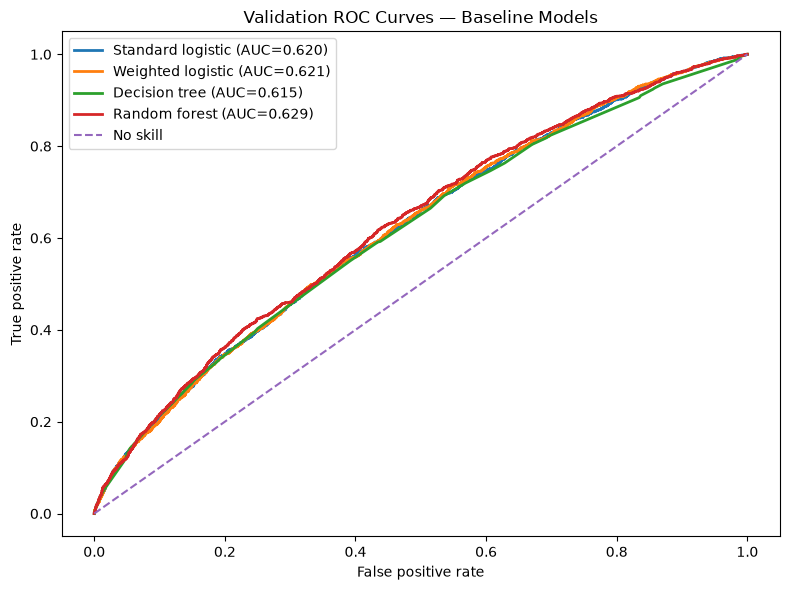

In [40]:
# Compare validation ROC curves

validation_probability_registry = {
    "Standard logistic": validation_probability_logistic_standard,
    "Weighted logistic": validation_probability_logistic_weighted,
    "Decision tree": validation_probability_decision_tree,
    "Random forest": validation_probability_random_forest,
}

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, probabilities in validation_probability_registry.items():

    fpr, tpr, _ = roc_curve(
        y_validation,
        probabilities,
    )

    auc = roc_auc_score(
        y_validation,
        probabilities,
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={auc:.3f})",
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="No skill",
)

ax.set_title("Validation ROC Curves — Baseline Models")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()

plt.tight_layout()
plt.show()

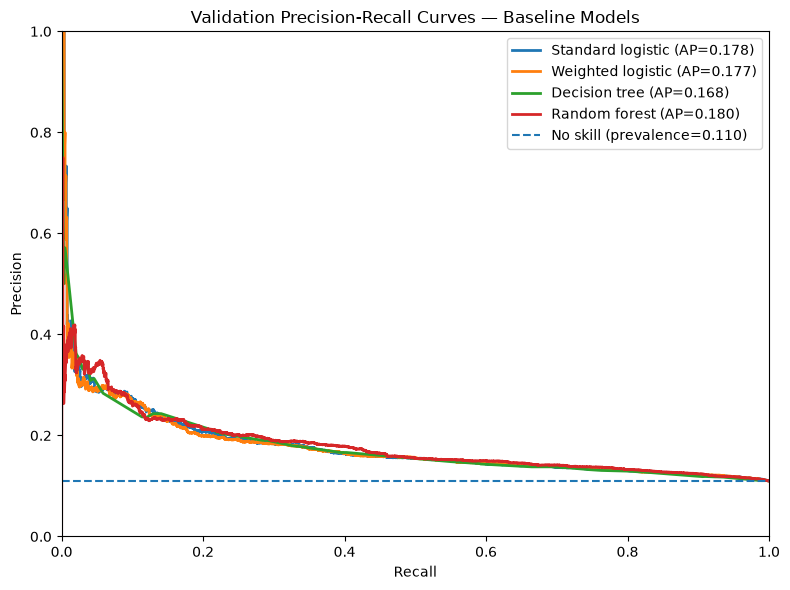

In [41]:
# Compare validation precision-recall curves

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, probabilities in validation_probability_registry.items():

    precision, recall, _ = precision_recall_curve(
        y_validation,
        probabilities,
    )

    ap = average_precision_score(
        y_validation,
        probabilities,
    )

    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP={ap:.3f})",
    )

# No-skill precision equals positive-class prevalence
validation_prevalence = y_validation.mean()

ax.axhline(
    validation_prevalence,
    linestyle="--",
    linewidth=1.5,
    label=f"No skill (prevalence={validation_prevalence:.3f})",
)

ax.set_title("Validation Precision-Recall Curves — Baseline Models")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

## 5K — Validation Threshold Analysis

The preceding comparisons evaluated each classifier at the conventional 0.50 probability threshold. For an imbalanced readmission outcome, however, 0.50 is not necessarily an appropriate operational decision threshold.

Threshold analysis is therefore performed using the validation partition only. The objective is not to maximize a single metric automatically, but to characterize the trade-off among:

- sensitivity (recall);
- specificity;
- precision;
- F1 score; and
- balanced accuracy.

Particular attention is given to sensitivity because false-negative predictions correspond to readmissions that would not be identified for potential intervention.

Three complementary threshold-selection perspectives are examined:

1. the threshold maximizing F1 score;
2. the threshold maximizing balanced accuracy; and
3. thresholds capable of achieving clinically interpretable sensitivity targets.

These analyses are exploratory model-selection procedures. The test partition remains untouched.

In [42]:
# Define reusable threshold-analysis utility


def threshold_sweep(y_true, y_probability, thresholds=None):

    if thresholds is None:
        thresholds = np.arange(0.01, 1.00, 0.01)

    records = []

    y_true = np.asarray(y_true)
    y_probability = np.asarray(y_probability)

    for threshold in thresholds:

        y_pred = (y_probability >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        precision = tp / (tp + fp) if (tp + fp) else 0.0

        balanced_accuracy = (sensitivity + specificity) / 2

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0,
        )

        records.append(
            {
                "threshold": threshold,
                "sensitivity": sensitivity,
                "specificity": specificity,
                "precision": precision,
                "balanced_accuracy": balanced_accuracy,
                "f1": f1,
                "tn": int(tn),
                "fp": int(fp),
                "fn": int(fn),
                "tp": int(tp),
            }
        )

    return pd.DataFrame(records)

In [43]:
# Sweep validation thresholds for all candidate models

threshold_results = {}

for model_name, probabilities in validation_probability_registry.items():

    threshold_results[model_name] = threshold_sweep(
        y_validation,
        probabilities,
    )

    print(
        f"{model_name:<20} "
        f"thresholds evaluated: "
        f"{len(threshold_results[model_name]):,}"
    )

Standard logistic    thresholds evaluated: 99
Weighted logistic    thresholds evaluated: 99
Decision tree        thresholds evaluated: 99
Random forest        thresholds evaluated: 99


In [44]:
# Identify metric-optimal validation thresholds

optimal_threshold_records = []

for model_name, results in threshold_results.items():

    best_f1 = results.loc[results["f1"].idxmax()]

    best_balanced = results.loc[results["balanced_accuracy"].idxmax()]

    optimal_threshold_records.append(
        {
            "model": model_name,
            "criterion": "Maximum F1",
            **best_f1.to_dict(),
        }
    )

    optimal_threshold_records.append(
        {
            "model": model_name,
            "criterion": "Maximum balanced accuracy",
            **best_balanced.to_dict(),
        }
    )

optimal_threshold_summary = pd.DataFrame(optimal_threshold_records)

optimal_threshold_summary[
    [
        "model",
        "criterion",
        "threshold",
        "sensitivity",
        "specificity",
        "precision",
        "balanced_accuracy",
        "f1",
    ]
].round(4)

,model,criterion,threshold,sensitivity,specificity,precision,balanced_accuracy,f1
0,Standard logistic,Maximum F1,0.11,0.5133,0.6495,0.1535,0.5814,0.2363
1,Standard logistic,Maximum balanced accuracy,0.11,0.5133,0.6495,0.1535,0.5814,0.2363
2,Weighted logistic,Maximum F1,0.50,0.5012,0.6617,0.1551,0.5815,0.2368
3,Weighted logistic,Maximum balanced accuracy,0.46,0.6286,0.5370,0.1439,0.5828,0.2342
4,Decision tree,Maximum F1,0.51,0.4028,0.7499,0.1663,0.5763,0.2354
5,Decision tree,Maximum balanced accuracy,0.50,0.5501,0.6083,0.1482,0.5792,0.2335
6,Random forest,Maximum F1,0.52,0.4028,0.7694,0.1778,0.5861,0.2467
7,Random forest,Maximum balanced accuracy,0.46,0.6238,0.5569,0.1485,0.5903,0.2398


In [45]:
# Identify thresholds meeting predefined sensitivity targets

sensitivity_targets = [0.60, 0.70, 0.80]

sensitivity_target_records = []

for model_name, results in threshold_results.items():

    for target in sensitivity_targets:

        eligible = results[results["sensitivity"] >= target]

        if eligible.empty:
            continue

        # Among thresholds satisfying the sensitivity target,
        # retain the operating point with greatest specificity.
        selected = eligible.loc[eligible["specificity"].idxmax()]

        sensitivity_target_records.append(
            {
                "model": model_name,
                "target_sensitivity": target,
                **selected.to_dict(),
            }
        )

sensitivity_target_summary = pd.DataFrame(sensitivity_target_records)

sensitivity_target_summary[
    [
        "model",
        "target_sensitivity",
        "threshold",
        "sensitivity",
        "specificity",
        "precision",
        "balanced_accuracy",
        "f1",
        "fp",
        "fn",
        "tp",
    ]
].round(4)

,model,target_sensitivity,threshold,sensitivity,specificity,precision,balanced_accuracy,f1,fp,fn,tp
0,Standard logistic,0.6,0.09,0.6950,0.4619,0.1379,0.5785,0.2302,7195.0,505.0,1151.0
1,Standard logistic,0.7,0.08,0.7977,0.3429,0.1307,0.5703,0.2246,8786.0,335.0,1321.0
2,Standard logistic,0.8,0.07,0.8792,0.2261,0.1233,0.5527,0.2163,10348.0,200.0,1456.0
3,Weighted logistic,0.6,0.46,0.6286,0.5370,0.1439,0.5828,0.2342,6191.0,615.0,1041.0
4,Weighted logistic,0.7,0.43,0.7228,0.4344,0.1366,0.5786,0.2298,7563.0,459.0,1197.0
5,Weighted logistic,0.8,0.40,0.8122,0.3279,0.1302,0.5701,0.2244,8986.0,311.0,1345.0
6,Decision tree,0.6,0.47,0.6564,0.4941,0.1385,0.5753,0.2287,6764.0,569.0,1087.0
7,Decision tree,0.7,0.44,0.7198,0.4314,0.1355,0.5756,0.2281,7603.0,464.0,1192.0
8,Decision tree,0.8,0.41,0.8188,0.3066,0.1276,0.5627,0.2208,9271.0,300.0,1356.0
9,Random forest,0.6,0.46,0.6238,0.5569,0.1485,0.5903,0.2398,5925.0,623.0,1033.0


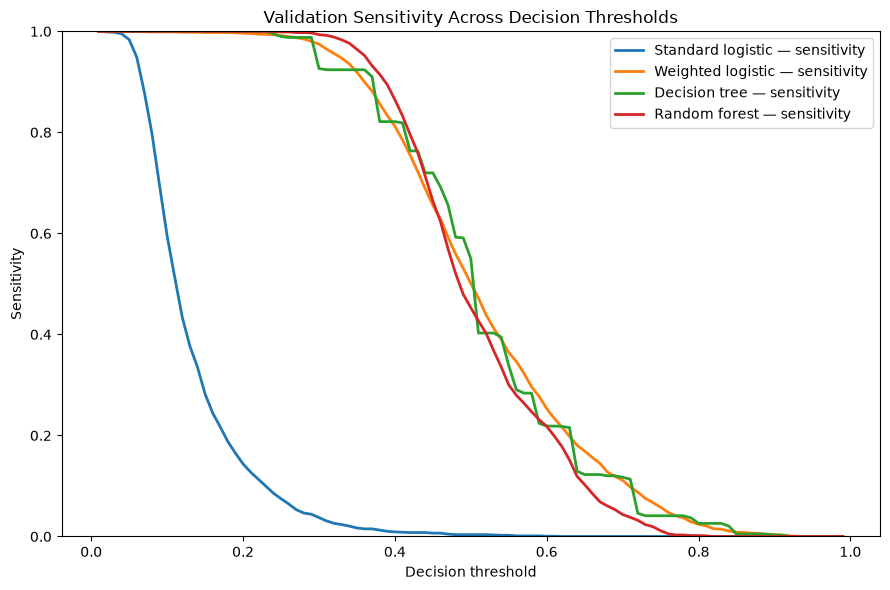

In [46]:
# Visualize validation sensitivity-specificity trade-offs

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, results in threshold_results.items():

    ax.plot(
        results["threshold"],
        results["sensitivity"],
        linewidth=2,
        label=f"{model_name} — sensitivity",
    )

ax.set_title("Validation Sensitivity Across Decision Thresholds")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Sensitivity")
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

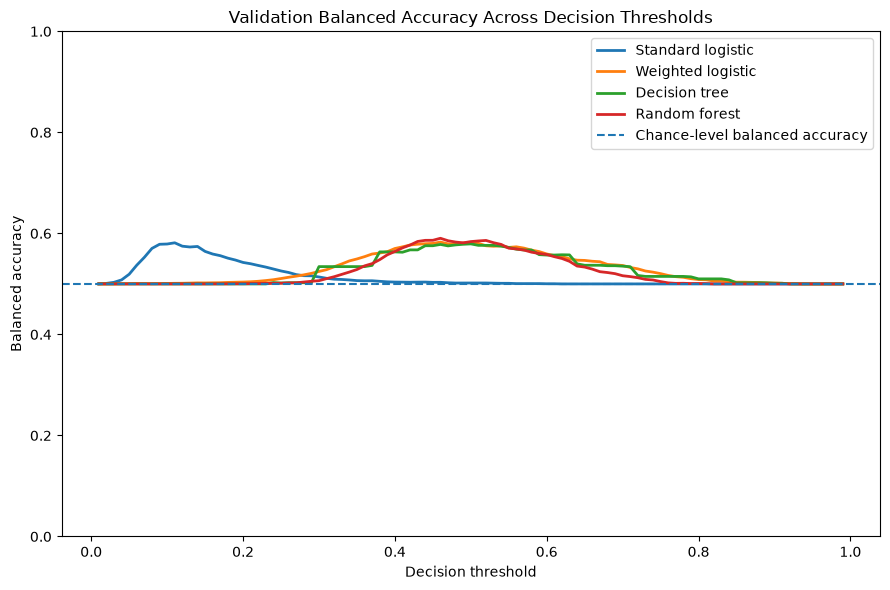

In [47]:
# Visualize balanced accuracy across thresholds

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, results in threshold_results.items():

    ax.plot(
        results["threshold"],
        results["balanced_accuracy"],
        linewidth=2,
        label=model_name,
    )

ax.set_title("Validation Balanced Accuracy Across Decision Thresholds")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0, 1)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1.5,
    label="Chance-level balanced accuracy",
)

ax.legend()

plt.tight_layout()
plt.show()

In [48]:
# Print compact threshold-analysis summaries for interpretation

print("OPTIMAL VALIDATION THRESHOLDS")
print("=" * 95)

optimal_display = optimal_threshold_summary[
    [
        "model",
        "criterion",
        "threshold",
        "sensitivity",
        "specificity",
        "precision",
        "balanced_accuracy",
        "f1",
    ]
].copy()

print(optimal_display.round(4).to_string(index=False))


print("\n\nSENSITIVITY-TARGET OPERATING POINTS")
print("=" * 115)

sensitivity_display = sensitivity_target_summary[
    [
        "model",
        "target_sensitivity",
        "threshold",
        "sensitivity",
        "specificity",
        "precision",
        "balanced_accuracy",
        "f1",
        "fp",
        "fn",
        "tp",
    ]
].copy()

print(sensitivity_display.round(4).to_string(index=False))

OPTIMAL VALIDATION THRESHOLDS
            model                 criterion  threshold  sensitivity  specificity  precision  balanced_accuracy     f1
Standard logistic                Maximum F1       0.11       0.5133       0.6495     0.1535             0.5814 0.2363
Standard logistic Maximum balanced accuracy       0.11       0.5133       0.6495     0.1535             0.5814 0.2363
Weighted logistic                Maximum F1       0.50       0.5012       0.6617     0.1551             0.5815 0.2368
Weighted logistic Maximum balanced accuracy       0.46       0.6286       0.5370     0.1439             0.5828 0.2342
    Decision tree                Maximum F1       0.51       0.4028       0.7499     0.1663             0.5763 0.2354
    Decision tree Maximum balanced accuracy       0.50       0.5501       0.6083     0.1482             0.5792 0.2335
    Random forest                Maximum F1       0.52       0.4028       0.7694     0.1778             0.5861 0.2467
    Random forest Maximum 

### Threshold-analysis interpretation

Validation threshold analysis demonstrates that the conventional 0.50 cutoff is not directly comparable across models because the candidate classifiers generate probabilities on substantially different scales.

The standard logistic regression model is the clearest example: although its discrimination is comparable with the other baseline models, its useful decision thresholds occur near the observed readmission prevalence rather than near 0.50.

Class weighting substantially shifts the logistic-regression probability distribution, causing its useful operating thresholds to occur closer to 0.50. The decision-tree and random-forest baselines exhibit similar threshold ranges.

Across all models, higher sensitivity requires accepting lower specificity and a larger number of false-positive intervention flags. Threshold choice should therefore be based on the intended operational cost of missed readmissions versus unnecessary follow-up rather than on accuracy alone.

Thresholds were selected exclusively from the validation partition. The test partition remains untouched.

### 5K Threshold-analysis interpretation

Validation threshold analysis demonstrates that the conventional 0.50 cutoff is not directly comparable across candidate models because their predicted probabilities occupy substantially different ranges.

This effect is most pronounced for standard logistic regression. Although its validation ROC-AUC is comparable with the other baseline models, the model produces probabilities concentrated near the underlying readmission prevalence. Consequently, the conventional 0.50 threshold identifies almost no positive cases, whereas a validation-selected threshold near 0.11 produces a substantially more balanced sensitivity-specificity trade-off.

Class weighting shifts the logistic-regression probability distribution upward, placing useful operating thresholds closer to 0.50. The decision-tree and random-forest baselines exhibit similar operating ranges.

No single threshold dominates across clinical objectives. Lower thresholds increase sensitivity at the cost of specificity and precision, while higher thresholds reduce false-positive flags but miss a larger proportion of readmissions. For example, operating near 80% sensitivity requires substantially lower specificity across all candidate models.

These results indicate that threshold selection should ultimately reflect the operational cost of missed readmissions relative to unnecessary follow-up interventions rather than relying on accuracy or the conventional 0.50 cutoff alone.

All threshold selection and comparison in this section use the validation partition exclusively. The test partition remains untouched.

## 5L — Probability Calibration Assessment

Discrimination metrics evaluate how effectively a model ranks encounters by readmission risk, but they do not establish whether predicted probabilities correspond to observed event frequencies.

Probability calibration is particularly important when model outputs are intended to support risk stratification or clinical decision-making. A predicted readmission probability of 0.20, for example, is most interpretable when approximately 20% of encounters receiving similar predictions are actually readmitted.

Calibration is therefore assessed on the validation partition using reliability curves and Brier scores. The analysis complements ROC-AUC and average precision by distinguishing ranking performance from probability accuracy.

Because class weighting alters the effective class distribution used during model estimation, weighted classifiers may produce useful rankings while generating probabilities that are not directly calibrated to the observed readmission prevalence.

The test partition remains untouched.

In [49]:
# Construct validation calibration curves

calibration_records = []
calibration_summary = []

for model_name, probabilities in validation_probability_registry.items():

    prob_true, prob_pred = calibration_curve(
        y_validation,
        probabilities,
        n_bins=10,
        strategy="quantile",
    )

    brier = brier_score_loss(
        y_validation,
        probabilities,
    )

    calibration_summary.append(
        {
            "model": model_name,
            "brier_score": brier,
            "mean_predicted_probability": np.mean(probabilities),
            "observed_prevalence": np.mean(y_validation),
        }
    )

    calibration_records.append(
        pd.DataFrame(
            {
                "model": model_name,
                "mean_predicted_probability": prob_pred,
                "observed_event_rate": prob_true,
            }
        )
    )

calibration_summary = (
    pd.DataFrame(calibration_summary).sort_values("brier_score").reset_index(drop=True)
)

calibration_data = pd.concat(
    calibration_records,
    ignore_index=True,
)

calibration_summary.round(4)

,model,brier_score,mean_predicted_probability,observed_prevalence
0,Standard logistic,0.0960,0.1093,0.1102
1,Random forest,0.2242,0.4655,0.1102
2,Weighted logistic,0.2293,0.4660,0.1102
3,Decision tree,0.2310,0.4697,0.1102


### Validation Reliability Curves

Reliability curves compare predicted readmission probabilities with the observed
readmission frequency within groups of encounters receiving similar predicted
risk estimates.

A perfectly calibrated model would follow the 45-degree reference line, where
predicted probability equals observed event frequency. Deviations from this line
indicate systematic over- or under-estimation of absolute readmission risk.

Because class weighting changes the effective class distribution used during
model estimation, weighted classifiers may retain useful discrimination while
producing probability estimates that are not directly calibrated to the observed
readmission prevalence.

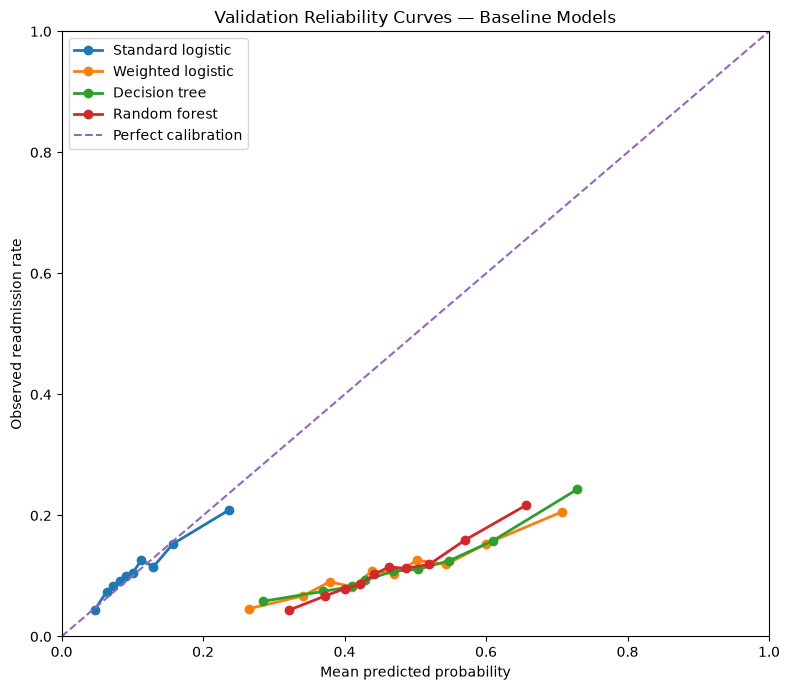

In [50]:
# Visualize validation reliability curves

fig, ax = plt.subplots(figsize=(8, 7))

for model_name in validation_probability_registry:
    model_calibration = calibration_data[calibration_data["model"] == model_name]

    ax.plot(
        model_calibration["mean_predicted_probability"],
        model_calibration["observed_event_rate"],
        marker="o",
        linewidth=2,
        label=model_name,
    )

# Perfect-calibration reference
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration",
)

ax.set_title("Validation Reliability Curves — Baseline Models")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed readmission rate")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

In [51]:
# Quantify reliability-curve calibration error

calibration_error_records = []

for model_name in calibration_data["model"].unique():

    model_calibration = calibration_data[calibration_data["model"] == model_name].copy()

    calibration_gap = (
        model_calibration["observed_event_rate"]
        - model_calibration["mean_predicted_probability"]
    )

    calibration_error_records.append(
        {
            "model": model_name,
            "mean_absolute_calibration_gap": np.mean(np.abs(calibration_gap)),
            "max_absolute_calibration_gap": np.max(np.abs(calibration_gap)),
        }
    )

calibration_error_summary = (
    pd.DataFrame(calibration_error_records)
    .merge(
        calibration_summary,
        on="model",
        how="left",
    )
    .sort_values("brier_score")
    .reset_index(drop=True)
)

calibration_error_summary[
    [
        "model",
        "brier_score",
        "mean_predicted_probability",
        "observed_prevalence",
        "mean_absolute_calibration_gap",
        "max_absolute_calibration_gap",
    ]
].round(4)

,model,brier_score,mean_predicted_probability,observed_prevalence,mean_absolute_calibration_gap,max_absolute_calibration_gap
0,Standard logistic,0.0960,0.1093,0.1102,0.0107,0.0276
1,Random forest,0.2242,0.4655,0.1102,0.3553,0.4396
2,Weighted logistic,0.2293,0.4660,0.1102,0.3558,0.5016
3,Decision tree,0.2310,0.4697,0.1102,0.3665,0.4858


In [52]:
# Summarize predicted-probability distributions

probability_distribution_records = []

for model_name, probabilities in validation_probability_registry.items():

    probability_distribution_records.append(
        {
            "model": model_name,
            "minimum": np.min(probabilities),
            "p10": np.quantile(probabilities, 0.10),
            "p25": np.quantile(probabilities, 0.25),
            "median": np.median(probabilities),
            "mean": np.mean(probabilities),
            "p75": np.quantile(probabilities, 0.75),
            "p90": np.quantile(probabilities, 0.90),
            "maximum": np.max(probabilities),
        }
    )

probability_distribution_summary = pd.DataFrame(probability_distribution_records)

probability_distribution_summary.round(4)

,model,minimum,p10,p25,median,mean,p75,p90,maximum
0,Standard logistic,0.0080,0.0578,0.0732,0.0952,0.1093,0.1294,0.1787,0.6127
1,Weighted logistic,0.0286,0.3178,0.3794,0.4542,0.4660,0.5425,0.6375,0.9338
2,Decision tree,0.2309,0.2913,0.3772,0.4775,0.4697,0.5457,0.6340,0.9188
3,Random forest,0.1530,0.3560,0.4002,0.4523,0.4655,0.5198,0.6117,0.8271


In [53]:
# Print compact calibration-error summary

print("VALIDATION CALIBRATION SUMMARY")
print("=" * 95)

print(
    calibration_error_summary[
        [
            "model",
            "brier_score",
            "mean_absolute_calibration_gap",
            "max_absolute_calibration_gap",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

VALIDATION CALIBRATION SUMMARY
            model  brier_score  mean_absolute_calibration_gap  max_absolute_calibration_gap
Standard logistic       0.0960                         0.0107                        0.0276
    Random forest       0.2242                         0.3553                        0.4396
Weighted logistic       0.2293                         0.3558                        0.5016
    Decision tree       0.2310                         0.3665                        0.4858


### Calibration interpretation

Calibration analysis reveals a substantial distinction between discrimination performance and probability reliability among the baseline models.

The standard logistic regression is markedly better calibrated than the class-weighted alternatives. Its mean predicted readmission probability (0.1093) closely matches the observed validation prevalence (0.1102), and it achieves the lowest Brier score (0.0960). Its mean absolute calibration gap is 0.0107, with a maximum absolute gap of only 0.0276 across the quantile-based reliability bins. The reliability curve correspondingly remains close to the perfect-calibration reference line.

In contrast, the class-weighted logistic regression, decision tree, and random forest produce mean predicted probabilities of approximately 0.47 despite an observed readmission prevalence of approximately 0.11. Their reliability curves fall substantially below the perfect-calibration line, indicating systematic overestimation of absolute readmission risk. Mean absolute calibration gaps range from approximately 0.355 to 0.367.

These findings do not imply that the class-weighted models lack predictive value. The random forest, for example, provides the strongest validation discrimination among the baseline candidates. Rather, class weighting has produced scores that remain useful for ranking encounters by relative risk but should not be interpreted directly as calibrated readmission probabilities without an additional calibration procedure.

Accordingly, subsequent model selection distinguishes discrimination and screening performance from probability calibration. All calibration analyses were performed exclusively on the validation partition; the test partition remains untouched.

## 5M — Baseline Model Selection

The preceding analyses evaluated four baseline approaches from complementary perspectives: discrimination, precision-recall performance, threshold-dependent classification behavior, and probability calibration.

Model selection is performed exclusively on the validation partition. The held-out test partition remains untouched until both the candidate model and its operating threshold have been selected.

For the present readmission-risk application, the primary objective is to identify encounters with elevated readmission risk while preserving a clinically interpretable trade-off between sensitivity and specificity. ROC-AUC and average precision are therefore used to assess ranking performance, while threshold analysis determines an appropriate classification operating point. Calibration is evaluated separately because a model may rank patients effectively even when its raw probability estimates should not be interpreted as absolute risks.

In [54]:
# Construct baseline model-selection summary

model_selection_summary = (
    validation_comparison[validation_comparison["model"] != "Prevalence benchmark"][
        [
            "model",
            "roc_auc",
            "average_precision",
            "brier_score",
            "balanced_accuracy",
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1",
        ]
    ]
    .merge(
        calibration_error_summary[
            [
                "model",
                "mean_absolute_calibration_gap",
            ]
        ],
        on="model",
        how="left",
    )
    .sort_values(
        ["roc_auc", "average_precision"],
        ascending=False,
    )
    .reset_index(drop=True)
)

model_selection_summary.round(4)

,model,roc_auc,average_precision,brier_score,balanced_accuracy,precision,recall_sensitivity,specificity,f1,mean_absolute_calibration_gap
0,Random forest baseline,0.6288,0.1799,0.2242,0.5838,0.1643,0.4529,0.7147,0.2411,NaN
1,Class-weighted logistic regression,0.6207,0.1771,0.2293,0.5815,0.1551,0.5012,0.6617,0.2368,NaN
2,Standard logistic regression,0.6198,0.1782,0.0960,0.5018,1.0000,0.0036,1.0000,0.0072,NaN
3,Decision tree baseline,0.6147,0.1685,0.2310,0.5792,0.1482,0.5501,0.6083,0.2335,NaN


In [55]:
print(model_selection_summary["model"].tolist())

['Random forest baseline', 'Class-weighted logistic regression', 'Standard logistic regression', 'Decision tree baseline']


In [56]:
# Quantify discrimination gains relative to standard logistic regression

standard_logistic_selection = model_selection_summary.loc[
    model_selection_summary["model"] == "Standard logistic regression"
].iloc[0]

random_forest_selection = model_selection_summary.loc[
    model_selection_summary["model"] == "Random forest baseline"
].iloc[0]

selection_gain_summary = pd.DataFrame(
    {
        "metric": [
            "ROC-AUC",
            "Average precision",
        ],
        "standard_logistic": [
            standard_logistic_selection["roc_auc"],
            standard_logistic_selection["average_precision"],
        ],
        "random_forest": [
            random_forest_selection["roc_auc"],
            random_forest_selection["average_precision"],
        ],
    }
)

selection_gain_summary["absolute_gain"] = (
    selection_gain_summary["random_forest"]
    - selection_gain_summary["standard_logistic"]
)

selection_gain_summary["relative_gain_pct"] = (
    selection_gain_summary["absolute_gain"]
    / selection_gain_summary["standard_logistic"]
    * 100
)

selection_gain_summary.round(4)

,metric,standard_logistic,random_forest,absolute_gain,relative_gain_pct
0,ROC-AUC,0.6198,0.6288,0.0090,1.4460
1,Average precision,0.1782,0.1799,0.0017,0.9539


In [57]:
# Select random-forest operating threshold for >=70% validation sensitivity

PRIMARY_MODEL = "Random forest"
TARGET_SENSITIVITY = 0.70

rf_target_candidates = sensitivity_target_summary[
    (sensitivity_target_summary["model"] == PRIMARY_MODEL)
    & (sensitivity_target_summary["target_sensitivity"] == TARGET_SENSITIVITY)
].copy()

assert len(rf_target_candidates) == 1, (
    "Expected exactly one random-forest operating point "
    "for the requested sensitivity target."
)

rf_operating_point = rf_target_candidates.iloc[0]

SELECTED_THRESHOLD = float(rf_operating_point["threshold"])

print("RANDOM-FOREST VALIDATION OPERATING POINT")
print("=" * 70)

display_columns = [
    "model",
    "target_sensitivity",
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "balanced_accuracy",
    "f1",
    "fp",
    "fn",
    "tp",
]

display_values = rf_operating_point[display_columns].copy()

for col in [
    "target_sensitivity",
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "balanced_accuracy",
    "f1",
]:
    display_values[col] = round(float(display_values[col]), 4)

print(display_values.to_string())

RANDOM-FOREST VALIDATION OPERATING POINT
model                 Random forest
target_sensitivity              0.7
threshold                      0.44
sensitivity                  0.7132
specificity                  0.4594
precision                    0.1404
balanced_accuracy            0.5863
f1                           0.2347
fp                           7229.0
fn                            475.0
tp                           1181.0


In [58]:
# Lock baseline model-selection decision before test evaluation

baseline_selection = {
    "primary_model": PRIMARY_MODEL,
    "model_object": "random_forest",
    "operating_objective": "validation sensitivity >= 0.70",
    "target_sensitivity": TARGET_SENSITIVITY,
    "selected_threshold": SELECTED_THRESHOLD,
    "probability_reference_model": "Standard logistic regression",
    "selection_partition": "validation",
    "test_used_for_selection": False,
}

print("BASELINE MODEL SELECTION")
print("=" * 70)

for key, value in baseline_selection.items():
    print(f"{key:30s}: {value}")

BASELINE MODEL SELECTION
primary_model                 : Random forest
model_object                  : random_forest
operating_objective           : validation sensitivity >= 0.70
target_sensitivity            : 0.7
selected_threshold            : 0.44
probability_reference_model   : Standard logistic regression
selection_partition           : validation
test_used_for_selection       : False


### Baseline model-selection decision

Baseline model selection was performed exclusively on the validation partition.

Among the candidate classifiers, the random forest achieved the strongest discrimination, with validation ROC-AUC of 0.6288 and average precision of 0.1799. Relative to standard logistic regression, these represent modest absolute improvements of 0.0090 in ROC-AUC and 0.0017 in average precision.

Standard logistic regression remained substantially better calibrated, with a Brier score of 0.0960 and predicted probabilities closely aligned with the observed validation prevalence. The class-weighted tree-based models, including the random forest, produced useful relative-risk rankings but substantially overestimated absolute readmission probability.

Because the intended baseline use case emphasizes identification of patients at elevated risk rather than direct interpretation of raw predicted probabilities, the random forest is selected as the primary screening classifier.

The operating threshold was selected from the validation partition using a prespecified sensitivity objective of at least 70%. The resulting random-forest threshold of 0.44 achieved validation sensitivity of 0.7132, specificity of 0.4594, precision of 0.1404, and balanced accuracy of 0.5863.

The standard logistic regression is retained as the probability-calibrated reference model.

The selected model, operating objective, and decision threshold are now fixed. No test observations were used during model or threshold selection.

## 5N — Final Held-Out Test Evaluation

The primary baseline model and operating threshold were selected using the validation partition before examining final test performance.

The random forest is evaluated on the untouched test partition using the locked probability threshold of 0.44. No model parameters, preprocessing transformations, feature definitions, or decision thresholds are modified based on test-set results.

Evaluation includes both threshold-independent discrimination metrics and threshold-dependent classification performance.

The standard logistic regression is also evaluated as a secondary probability-calibrated reference model, but it is not used to revise the primary model-selection decision.

In [59]:
# Generate final random-forest test probabilities

test_probability_random_forest = random_forest.predict_proba(X_test_ready)[:, 1]

print("Random-forest test probabilities")
print("-" * 60)

print(f"Minimum probability: " f"{test_probability_random_forest.min():.4f}")
print(f"Mean probability:    " f"{test_probability_random_forest.mean():.4f}")
print(f"Median probability:  " f"{np.median(test_probability_random_forest):.4f}")
print(f"Maximum probability: " f"{test_probability_random_forest.max():.4f}")

assert len(test_probability_random_forest) == len(y_test)
assert np.isfinite(test_probability_random_forest).all()

assert (
    (test_probability_random_forest >= 0) & (test_probability_random_forest <= 1)
).all()

print("\n✓ Final test probabilities are valid.")

Random-forest test probabilities
------------------------------------------------------------
Minimum probability: 0.1622
Mean probability:    0.4672
Median probability:  0.4525
Maximum probability: 0.8345

✓ Final test probabilities are valid.


In [60]:
# Evaluate selected random forest on untouched test partition

random_forest_test_result = evaluate_binary_classifier(
    y_true=y_test,
    y_probability=test_probability_random_forest,
    threshold=SELECTED_THRESHOLD,
    model_name="Selected random forest — test",
)

display_model_metrics(random_forest_test_result)

Selected random forest — test
------------------------------------------------------------
Threshold:          0.440
ROC-AUC:            0.6491
Average precision:  0.2029
Brier score:        0.2241

Accuracy:           0.4924
Balanced accuracy:  0.5966
Precision:          0.1444
Recall/Sensitivity: 0.7304
Specificity:        0.4629
NPV:                0.9326
F1:                 0.2411

Confusion matrix counts: TN=6,267, FP=7,272, FN=453, TP=1,227


In [61]:
# Compare locked validation operating point with final test performance

validation_test_comparison = pd.DataFrame(
    [
        {
            "partition": "Validation",
            "roc_auc": random_forest_result["roc_auc"],
            "average_precision": random_forest_result["average_precision"],
            "brier_score": random_forest_result["brier_score"],
            "balanced_accuracy": rf_operating_point["balanced_accuracy"],
            "precision": rf_operating_point["precision"],
            "recall_sensitivity": rf_operating_point["sensitivity"],
            "specificity": rf_operating_point["specificity"],
            "f1": rf_operating_point["f1"],
        },
        {
            "partition": "Test",
            "roc_auc": random_forest_test_result["roc_auc"],
            "average_precision": random_forest_test_result["average_precision"],
            "brier_score": random_forest_test_result["brier_score"],
            "balanced_accuracy": random_forest_test_result["balanced_accuracy"],
            "precision": random_forest_test_result["precision"],
            "recall_sensitivity": random_forest_test_result["recall_sensitivity"],
            "specificity": random_forest_test_result["specificity"],
            "f1": random_forest_test_result["f1"],
        },
    ]
)

validation_test_comparison.round(4)

,partition,roc_auc,average_precision,brier_score,balanced_accuracy,precision,recall_sensitivity,specificity,f1
0,Validation,0.6288,0.1799,0.2242,0.5863,0.1404,0.7132,0.4594,0.2347
1,Test,0.6491,0.2029,0.2241,0.5966,0.1444,0.7304,0.4629,0.2411


In [62]:
# Generate standard-logistic test probabilities

test_probability_logistic_standard = logistic_standard.predict_proba(X_test_ready)[:, 1]

print("Standard-logistic test probabilities")
print("-" * 60)

print(f"Minimum probability: " f"{test_probability_logistic_standard.min():.4f}")
print(f"Mean probability:    " f"{test_probability_logistic_standard.mean():.4f}")
print(f"Median probability:  " f"{np.median(test_probability_logistic_standard):.4f}")
print(f"Maximum probability: " f"{test_probability_logistic_standard.max():.4f}")

assert len(test_probability_logistic_standard) == len(y_test)
assert np.isfinite(test_probability_logistic_standard).all()

assert (
    (test_probability_logistic_standard >= 0)
    & (test_probability_logistic_standard <= 1)
).all()

print("\n✓ Standard-logistic test probabilities are valid.")

Standard-logistic test probabilities
------------------------------------------------------------
Minimum probability: 0.0077
Mean probability:    0.1110
Median probability:  0.0957
Maximum probability: 0.7561

✓ Standard-logistic test probabilities are valid.


In [63]:
# Evaluate standard logistic regression as probability reference

logistic_standard_test_result = evaluate_binary_classifier(
    y_true=y_test,
    y_probability=test_probability_logistic_standard,
    threshold=0.50,
    model_name="Standard logistic regression — test",
)

display_model_metrics(logistic_standard_test_result)

Standard logistic regression — test
------------------------------------------------------------
Threshold:          0.500
ROC-AUC:            0.6451
Average precision:  0.2029
Brier score:        0.0947

Accuracy:           0.8897
Balanced accuracy:  0.5024
Precision:          0.5625
Recall/Sensitivity: 0.0054
Specificity:        0.9995
NPV:                0.8901
F1:                 0.0106

Confusion matrix counts: TN=13,532, FP=7, FN=1,671, TP=9


In [64]:
# Final held-out test comparison

final_test_comparison = pd.DataFrame(
    [
        {
            "model": "Random forest — selected screening model",
            "threshold": SELECTED_THRESHOLD,
            "roc_auc": random_forest_test_result["roc_auc"],
            "average_precision": random_forest_test_result["average_precision"],
            "brier_score": random_forest_test_result["brier_score"],
            "balanced_accuracy": random_forest_test_result["balanced_accuracy"],
            "precision": random_forest_test_result["precision"],
            "sensitivity": random_forest_test_result["recall_sensitivity"],
            "specificity": random_forest_test_result["specificity"],
            "f1": random_forest_test_result["f1"],
        },
        {
            "model": "Standard logistic — probability reference",
            "threshold": 0.50,
            "roc_auc": logistic_standard_test_result["roc_auc"],
            "average_precision": logistic_standard_test_result["average_precision"],
            "brier_score": logistic_standard_test_result["brier_score"],
            "balanced_accuracy": logistic_standard_test_result["balanced_accuracy"],
            "precision": logistic_standard_test_result["precision"],
            "sensitivity": logistic_standard_test_result["recall_sensitivity"],
            "specificity": logistic_standard_test_result["specificity"],
            "f1": logistic_standard_test_result["f1"],
        },
    ]
)

final_test_comparison.round(4)

,model,threshold,roc_auc,average_precision,brier_score,balanced_accuracy,precision,sensitivity,specificity,f1
0,Random forest — selected screening model,0.44,0.6491,0.2029,0.2241,0.5966,0.1444,0.7304,0.4629,0.2411
1,Standard logistic — probability reference,0.50,0.6451,0.2029,0.0947,0.5024,0.5625,0.0054,0.9995,0.0106


### Final held-out test interpretation

The locked random-forest screening model generalized consistently to the previously untouched test partition. At the validation-selected threshold of 0.44, test ROC-AUC was 0.6491 and average precision was 0.2029. Sensitivity reached 0.7304, exceeding the prespecified 70% screening target, while specificity was 0.4629 and balanced accuracy was 0.5966.

Performance did not deteriorate relative to validation. Test ROC-AUC, average precision, sensitivity, specificity, balanced accuracy, precision, and F1 were all comparable to or modestly higher than their validation values. This provides evidence that the selected baseline operating rule was not dependent on unusually favorable validation performance.

The standard logistic regression produced similar test discrimination (ROC-AUC 0.6451; average precision 0.2029) but substantially better probability calibration, with a Brier score of 0.0947 compared with 0.2241 for the random forest. Its mean predicted probability of 0.1110 was also closely aligned with the observed readmission prevalence.

At the conventional 0.50 classification threshold, however, standard logistic regression identified very few positive encounters, producing sensitivity of only 0.0054. This should not be interpreted as evidence of poor discrimination. Rather, because predicted probabilities were concentrated substantially below 0.50, the conventional threshold is inappropriate for a sensitivity-oriented screening objective.

The random forest is therefore retained as the primary baseline screening model using the validation-selected threshold of 0.44, while standard logistic regression remains the better-calibrated probability reference. Random-forest probabilities should be interpreted primarily as relative risk scores rather than directly as calibrated absolute readmission probabilities.

No model parameters or decision thresholds were modified after examination of the test partition.

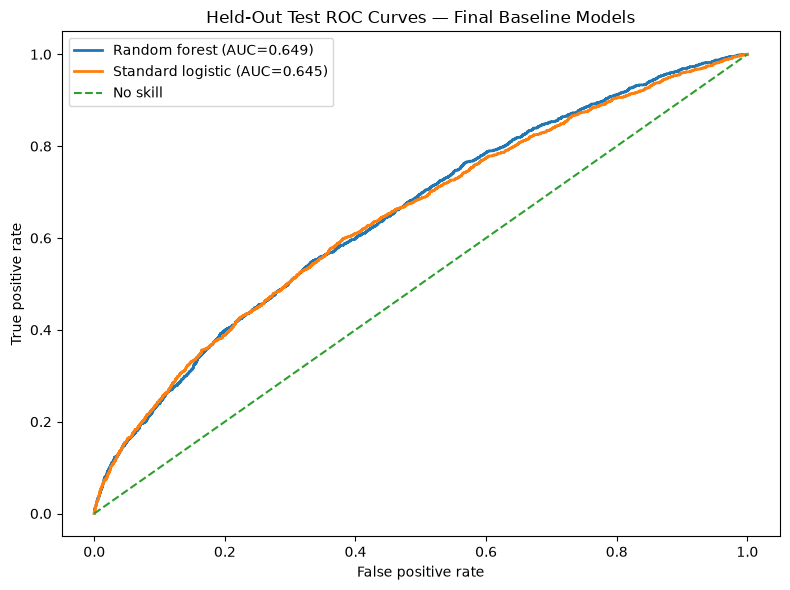

In [65]:
# Compare final held-out test ROC curves

fig, ax = plt.subplots(figsize=(8, 6))

final_test_probabilities = {
    "Random forest": test_probability_random_forest,
    "Standard logistic": test_probability_logistic_standard,
}

for model_name, probabilities in final_test_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities,
    )

    auc = roc_auc_score(
        y_test,
        probabilities,
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={auc:.3f})",
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="No skill",
)

ax.set_title("Held-Out Test ROC Curves — Final Baseline Models")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()

plt.tight_layout()
plt.show()

## 5O — Baseline Model Interpretation

Predictive performance alone does not explain which encounter characteristics contribute most strongly to estimated readmission risk. This section examines the fitted baseline models to identify the variables most influential in their predictions.

Random-forest feature importance is first used to characterize the variables contributing most strongly to the selected screening model. Because categorical predictors were one-hot encoded during preprocessing, transformed feature-level importances are examined before being related back to their original clinical and utilization variables.

Standard logistic-regression coefficients are then examined as a complementary interpretation. Unlike random-forest feature importance, logistic coefficients retain directionality and therefore help distinguish characteristics associated with higher versus lower predicted readmission risk.

These analyses describe associations learned by the predictive models and should not be interpreted as causal effects.

In [66]:
# Extract transformed feature names for model interpretation

feature_names = preprocessor.get_feature_names_out()

print("Transformed feature count:", len(feature_names))
print("\nFirst 20 transformed features:")
for feature in feature_names[:20]:
    print(feature)

print("\nModel feature counts:")
print("Random forest:", random_forest.n_features_in_)
print("Standard logistic:", logistic_standard.n_features_in_)

assert len(feature_names) == random_forest.n_features_in_
assert len(feature_names) == logistic_standard.n_features_in_

print("\n✓ Transformed feature names align with fitted baseline models.")

Transformed feature count: 213

First 20 transformed features:
numeric__time_in_hospital
numeric__num_lab_procedures
numeric__num_procedures
numeric__num_medications
numeric__number_outpatient
numeric__number_emergency
numeric__number_inpatient
numeric__number_diagnoses
numeric__prior_utilization_total
numeric__log1p_number_outpatient
numeric__log1p_number_emergency
numeric__log1p_number_inpatient
numeric__log1p_prior_utilization_total
categorical__race_AfricanAmerican
categorical__race_Asian
categorical__race_Caucasian
categorical__race_Hispanic
categorical__race_Other
categorical__race_Unknown
categorical__gender_Female

Model feature counts:
Random forest: 213
Standard logistic: 213

✓ Transformed feature names align with fitted baseline models.


In [67]:
# Rank transformed features by random-forest importance

rf_feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": random_forest.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

rf_feature_importance["cumulative_importance"] = rf_feature_importance[
    "importance"
].cumsum()

print("RANDOM-FOREST FEATURE IMPORTANCE")
print("=" * 70)

print(rf_feature_importance.head(25).round(4).to_string(index=False))

print(
    "\nTotal importance:",
    round(rf_feature_importance["importance"].sum(), 6),
)

print(
    "Features required for 50% cumulative importance:",
    int((rf_feature_importance["cumulative_importance"] < 0.50).sum() + 1),
)

print(
    "Features required for 80% cumulative importance:",
    int((rf_feature_importance["cumulative_importance"] < 0.80).sum() + 1),
)

RANDOM-FOREST FEATURE IMPORTANCE
                                                      feature  importance  cumulative_importance
                                    numeric__number_inpatient      0.1435                 0.1435
                              numeric__log1p_number_inpatient      0.1267                 0.2702
                             numeric__prior_utilization_total      0.0971                 0.3673
                       numeric__log1p_prior_utilization_total      0.0873                 0.4547
                                    numeric__time_in_hospital      0.0387                 0.4933
                                     numeric__num_medications      0.0362                 0.5296
                                  numeric__num_lab_procedures      0.0320                 0.5616
                                    numeric__number_diagnoses      0.0311                 0.5926
                                    numeric__number_emergency      0.0240                 0.61

In [68]:
# Map transformed features to clinically meaningful source concepts


def map_feature_to_concept(feature):
    # Remove ColumnTransformer prefixes
    feature = feature.replace("numeric__", "").replace("categorical__", "")

    # Numeric variables and engineered variants
    numeric_concepts = {
        "time_in_hospital": "time_in_hospital",
        "num_lab_procedures": "num_lab_procedures",
        "num_procedures": "num_procedures",
        "num_medications": "num_medications",
        "number_outpatient": "number_outpatient",
        "number_emergency": "number_emergency",
        "number_inpatient": "number_inpatient",
        "number_diagnoses": "number_diagnoses",
        "prior_utilization_total": "prior_utilization_total",
        "log1p_number_outpatient": "number_outpatient",
        "log1p_number_emergency": "number_emergency",
        "log1p_number_inpatient": "number_inpatient",
        "log1p_prior_utilization_total": "prior_utilization_total",
    }

    if feature in numeric_concepts:
        return numeric_concepts[feature]

    # Recover source variable for one-hot encoded categorical features.
    # Match against known categorical columns rather than splitting at "_",
    # because source variable names themselves may contain underscores.
    categorical_candidates = sorted(
        CATEGORICAL_FEATURES,
        key=len,
        reverse=True,
    )

    for source_feature in categorical_candidates:
        if feature == source_feature or feature.startswith(source_feature + "_"):
            return source_feature

    return feature


rf_feature_importance["source_concept"] = rf_feature_importance["feature"].map(
    map_feature_to_concept
)

rf_concept_importance = (
    rf_feature_importance.groupby("source_concept", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

rf_concept_importance["cumulative_importance"] = rf_concept_importance[
    "importance"
].cumsum()

print("RANDOM-FOREST SOURCE-CONCEPT IMPORTANCE")
print("=" * 70)

print(rf_concept_importance.head(20).round(4).to_string(index=False))

print(
    "\nTotal aggregated importance:",
    round(rf_concept_importance["importance"].sum(), 6),
)

RANDOM-FOREST SOURCE-CONCEPT IMPORTANCE
              source_concept  importance  cumulative_importance
            number_inpatient      0.2702                 0.2702
     prior_utilization_total      0.1844                 0.4547
            number_emergency      0.0441                 0.4988
                         age      0.0410                 0.5397
            time_in_hospital      0.0387                 0.5784
               diag_1_family      0.0386                 0.6170
             num_medications      0.0362                 0.6533
          num_lab_procedures      0.0320                 0.6853
            number_diagnoses      0.0311                 0.7164
           medical_specialty      0.0299                 0.7463
                  payer_code      0.0264                 0.7727
               diag_3_family      0.0259                 0.7986
               diag_2_family      0.0253                 0.8239
                     insulin      0.0234                 0.8473


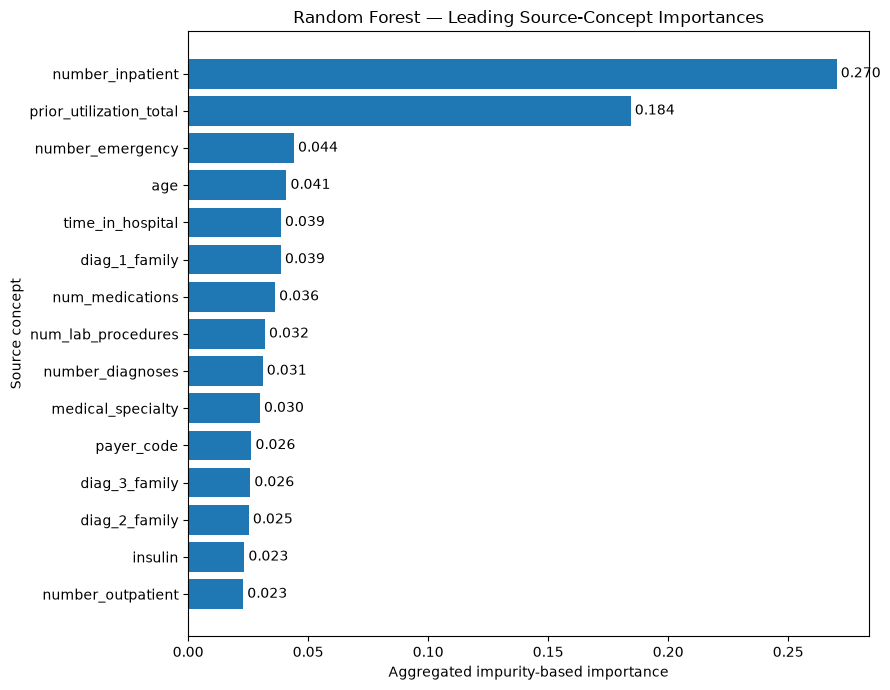

In [69]:
# Visualize leading random-forest source-concept importances

TOP_N_CONCEPTS = 15

rf_top_concepts = rf_concept_importance.head(TOP_N_CONCEPTS).sort_values(
    "importance", ascending=True
)

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(
    rf_top_concepts["source_concept"],
    rf_top_concepts["importance"],
)

for bar, importance in zip(
    bars,
    rf_top_concepts["importance"],
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {importance:.3f}",
        va="center",
    )

ax.set_title("Random Forest — Leading Source-Concept Importances")
ax.set_xlabel("Aggregated impurity-based importance")
ax.set_ylabel("Source concept")

plt.tight_layout()
plt.show()

### Random-Forest Importance Interpretation

The selected random-forest baseline relies most strongly on measures of prior healthcare utilization. In particular, prior inpatient utilization and the engineered aggregate utilization measure account for a substantial share of total impurity-based feature importance.

Encounter characteristics such as age, time in hospital, medication burden, diagnosis family, laboratory-procedure volume, medical specialty, and payer category provide additional predictive information, but individually contribute considerably less than the strongest utilization measures.

These results suggest that recent patterns of healthcare use are particularly informative for ranking encounters by subsequent 30-day readmission risk in this dataset.

Interpretation should remain cautious because impurity-based random-forest importance does not indicate the direction of association and may distribute importance among correlated predictors. In addition, `prior_utilization_total` is mathematically related to the individual inpatient, outpatient, and emergency utilization variables. Feature importance therefore reflects predictive contribution within this specific fitted model rather than independent or causal clinical effects.

In [70]:
# Extract and rank standard-logistic coefficients

logistic_coefficients = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": logistic_standard.coef_[0],
    }
)

logistic_coefficients["absolute_coefficient"] = logistic_coefficients[
    "coefficient"
].abs()

logistic_coefficients = logistic_coefficients.sort_values(
    "absolute_coefficient",
    ascending=False,
).reset_index(drop=True)

print("STANDARD LOGISTIC REGRESSION — LARGEST COEFFICIENTS")
print("=" * 75)

print(
    logistic_coefficients[
        [
            "feature",
            "coefficient",
            "absolute_coefficient",
        ]
    ]
    .head(25)
    .round(4)
    .to_string(index=False)
)

STANDARD LOGISTIC REGRESSION — LARGEST COEFFICIENTS
                                                       feature  coefficient  absolute_coefficient
             categorical__diag_3_family_Pregnancy & childbirth      -1.1421                1.1421
                                       categorical__age_[0-10)      -1.0401                1.0401
       categorical__medical_specialty_Pediatrics-Endocrinology      -0.9451                0.9451
                              categorical__rosiglitazone_Other      -0.7700                0.7700
             categorical__diag_2_family_Pregnancy & childbirth      -0.7328                0.7328
            categorical__medical_specialty_Hematology/Oncology       0.5940                0.5940
                                    categorical__payer_code_WC      -0.5842                0.5842
             categorical__diag_1_family_Pregnancy & childbirth       0.5555                0.5555
                                  categorical__acarbose_Steady    

In [71]:
# Add training-set support for transformed features

X_train_transformed = X_train_ready

if sparse.issparse(X_train_transformed):
    feature_support = np.asarray((X_train_transformed != 0).sum(axis=0)).ravel()
else:
    feature_support = np.count_nonzero(
        X_train_transformed,
        axis=0,
    )

logistic_coefficients["nonzero_train_count"] = [
    feature_support[np.where(feature_names == feature)[0][0]]
    for feature in logistic_coefficients["feature"]
]

logistic_coefficients["nonzero_train_pct"] = (
    logistic_coefficients["nonzero_train_count"] / X_train_transformed.shape[0] * 100
)

print("LOGISTIC COEFFICIENTS WITH TRAINING SUPPORT")
print("=" * 90)

print(
    logistic_coefficients[
        [
            "feature",
            "coefficient",
            "absolute_coefficient",
            "nonzero_train_count",
            "nonzero_train_pct",
        ]
    ]
    .head(25)
    .round(4)
    .to_string(index=False)
)

LOGISTIC COEFFICIENTS WITH TRAINING SUPPORT
                                                       feature  coefficient  absolute_coefficient  nonzero_train_count  nonzero_train_pct
             categorical__diag_3_family_Pregnancy & childbirth      -1.1421                1.1421                  203             0.2838
                                       categorical__age_[0-10)      -1.0401                1.0401                  107             0.1496
       categorical__medical_specialty_Pediatrics-Endocrinology      -0.9451                0.9451                  103             0.1440
                              categorical__rosiglitazone_Other      -0.7700                0.7700                   63             0.0881
             categorical__diag_2_family_Pregnancy & childbirth      -0.7328                0.7328                  285             0.3985
            categorical__medical_specialty_Hematology/Oncology       0.5940                0.5940                  150          

### Logistic-Regression Coefficient Interpretation

The standard logistic-regression model provides a complementary directional view of the predictors associated with 30-day readmission risk. However, coefficient magnitude must be interpreted together with feature prevalence.

Several of the largest absolute coefficients correspond to sparse one-hot encoded categories with very limited representation in the training data. Large coefficients for these categories may therefore reflect unstable estimates associated with small subgroup sizes rather than broadly influential predictors.

For this reason, individual logistic-regression coefficients are treated as descriptive baseline evidence rather than definitive clinical effects. The random-forest source-concept importance analysis provides a more useful high-level view of the variables driving discrimination, while the standard logistic model remains valuable as the substantially better-calibrated probability reference.

Neither coefficient magnitude nor random-forest feature importance should be interpreted as evidence of causality.

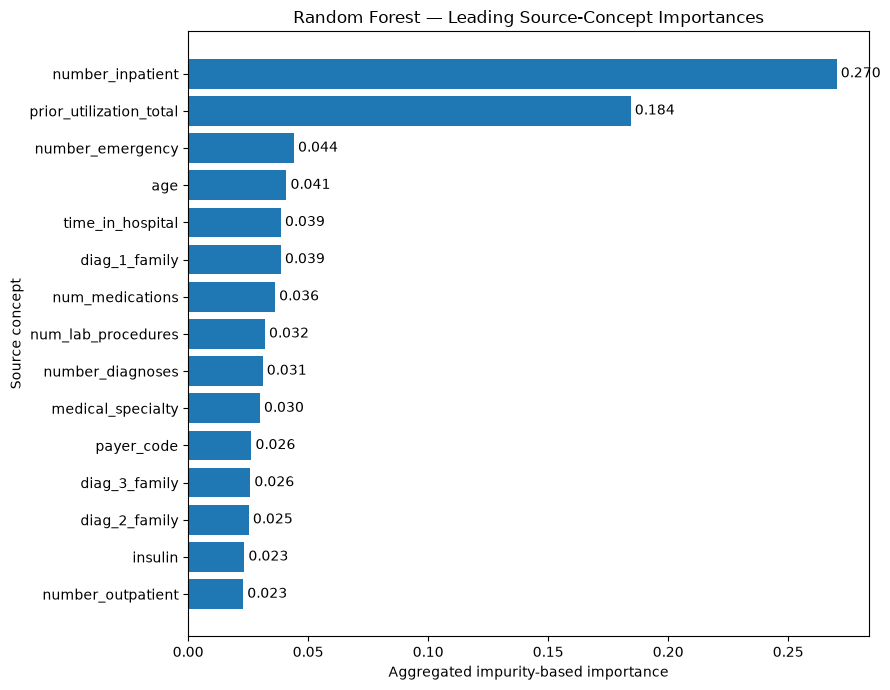

In [72]:
# Visualize leading random-forest source-concept importances

TOP_N_CONCEPTS = 15

rf_top_concepts = rf_concept_importance.head(TOP_N_CONCEPTS).sort_values(
    "importance", ascending=True
)

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(
    rf_top_concepts["source_concept"],
    rf_top_concepts["importance"],
)

for bar, importance in zip(
    bars,
    rf_top_concepts["importance"],
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {importance:.3f}",
        va="center",
    )

ax.set_title("Random Forest — Leading Source-Concept Importances")
ax.set_xlabel("Aggregated impurity-based importance")
ax.set_ylabel("Source concept")

plt.tight_layout()
plt.show()

In [73]:
# Summarize dominant source concepts

top_concept_summary = rf_concept_importance.head(15).copy()

top_concept_summary["importance_pct"] = top_concept_summary["importance"] * 100

top_concept_summary[
    [
        "source_concept",
        "importance",
        "importance_pct",
        "cumulative_importance",
    ]
].round(4)

,source_concept,importance,importance_pct,cumulative_importance
0,number_inpatient,0.2702,27.0233,0.2702
1,prior_utilization_total,0.1844,18.4420,0.4547
2,number_emergency,0.0441,4.4100,0.4988
3,age,0.0410,4.0966,0.5397
4,time_in_hospital,0.0387,3.8660,0.5784
5,diag_1_family,0.0386,3.8649,0.6170
6,num_medications,0.0362,3.6238,0.6533
7,num_lab_procedures,0.0320,3.2011,0.6853
8,number_diagnoses,0.0311,3.1086,0.7164
9,medical_specialty,0.0299,2.9918,0.7463


### Source-Concept Importance Summary

Random-forest importance is concentrated most heavily in measures of prior healthcare utilization. Prior inpatient utilization and the engineered aggregate prior-utilization measure account for a substantial share of total model importance, with additional contribution from emergency utilization, age, length of stay, diagnosis family, medication burden, laboratory procedures, and number of diagnoses.

This pattern is consistent with the broader exploratory analysis: patients with greater prior healthcare use tend to carry stronger readmission-risk signals than patients with little or no recent utilization history.

The importance values remain model-specific and should not be interpreted causally. In addition, several utilization variables are mathematically or clinically related, so importance may be distributed among correlated predictors.

In [74]:
# Persist interpretation artifacts

RF_IMPORTANCE_PATH = REPORTS_DIR / "random_forest_source_concept_importance.csv"
LOGISTIC_COEFFICIENT_PATH = REPORTS_DIR / "standard_logistic_coefficients.csv"

rf_concept_importance.to_csv(
    RF_IMPORTANCE_PATH,
    index=False,
)

logistic_coefficients.to_csv(
    LOGISTIC_COEFFICIENT_PATH,
    index=False,
)

print("Interpretation artifacts persisted")
print("-" * 70)
print(f"Random-forest concept importance: {RF_IMPORTANCE_PATH}")
print(f"Logistic coefficients:            {LOGISTIC_COEFFICIENT_PATH}")

assert RF_IMPORTANCE_PATH.exists()
assert LOGISTIC_COEFFICIENT_PATH.exists()

print("\n✓ Model-interpretation artifacts saved successfully.")

Interpretation artifacts persisted
----------------------------------------------------------------------
Random-forest concept importance: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\random_forest_source_concept_importance.csv
Logistic coefficients:            c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\standard_logistic_coefficients.csv

✓ Model-interpretation artifacts saved successfully.


## 5P — Persist Baseline Modeling Artifacts

The baseline modeling stage produced a selected screening model, a validation-derived operating threshold, a calibrated probability-reference model, model-selection evidence, final held-out test results, and model-interpretation artifacts.

This section persists the principal modeling outputs required for reproducibility and downstream analysis. The selected operating threshold remains the threshold chosen exclusively from validation data; the held-out test partition is used only for final performance estimation.

In [75]:
# Assemble baseline model metadata

baseline_model_metadata = {
    "selected_model": "Random forest",
    "selected_model_object": "random_forest",
    "selected_threshold": float(SELECTED_THRESHOLD),
    "threshold_selection_partition": "validation",
    "target_validation_sensitivity": float(TARGET_SENSITIVITY),
    "operating_objective": "validation sensitivity >= 0.70",
    "probability_reference_model": "Standard logistic regression",
    "test_used_for_model_selection": False,
    "n_transformed_features": int(len(feature_names)),
    "random_forest_test_roc_auc": float(random_forest_test_result["roc_auc"]),
    "random_forest_test_average_precision": float(
        random_forest_test_result["average_precision"]
    ),
    "random_forest_test_brier_score": float(random_forest_test_result["brier_score"]),
    "random_forest_test_sensitivity": float(
        random_forest_test_result["recall_sensitivity"]
    ),
    "random_forest_test_specificity": float(random_forest_test_result["specificity"]),
    "standard_logistic_test_roc_auc": float(logistic_standard_test_result["roc_auc"]),
    "standard_logistic_test_average_precision": float(
        logistic_standard_test_result["average_precision"]
    ),
    "standard_logistic_test_brier_score": float(
        logistic_standard_test_result["brier_score"]
    ),
}

baseline_model_metadata

{'selected_model': 'Random forest',
 'selected_model_object': 'random_forest',
 'selected_threshold': 0.44,
 'threshold_selection_partition': 'validation',
 'target_validation_sensitivity': 0.7,
 'operating_objective': 'validation sensitivity >= 0.70',
 'probability_reference_model': 'Standard logistic regression',
 'test_used_for_model_selection': False,
 'n_transformed_features': 213,
 'random_forest_test_roc_auc': 0.6491030321575415,
 'random_forest_test_average_precision': 0.20285486776137554,
 'random_forest_test_brier_score': 0.22408442086433747,
 'random_forest_test_sensitivity': 0.7303571428571428,
 'random_forest_test_specificity': 0.4628849988920895,
 'standard_logistic_test_roc_auc': 0.6451251499196325,
 'standard_logistic_test_average_precision': 0.2028902555268885,
 'standard_logistic_test_brier_score': 0.09474093007851382}

In [76]:
# Persist fitted baseline models

RANDOM_FOREST_MODEL_PATH = MODELS_DIR / "random_forest_baseline.joblib"
LOGISTIC_MODEL_PATH = MODELS_DIR / "standard_logistic_baseline.joblib"

joblib.dump(
    random_forest,
    RANDOM_FOREST_MODEL_PATH,
)

joblib.dump(
    logistic_standard,
    LOGISTIC_MODEL_PATH,
)

assert RANDOM_FOREST_MODEL_PATH.exists()
assert LOGISTIC_MODEL_PATH.exists()

print("Baseline models persisted")
print("-" * 70)
print(f"Random forest:     {RANDOM_FOREST_MODEL_PATH}")
print(f"Standard logistic: {LOGISTIC_MODEL_PATH}")
print("\n✓ Fitted baseline models saved successfully.")

Baseline models persisted
----------------------------------------------------------------------
Random forest:     c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\random_forest_baseline.joblib
Standard logistic: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\models\standard_logistic_baseline.joblib

✓ Fitted baseline models saved successfully.


In [77]:
# Persist baseline metadata and evaluation tables

import json

BASELINE_METADATA_PATH = REPORTS_DIR / "baseline_model_metadata.json"
FINAL_TEST_RESULTS_PATH = REPORTS_DIR / "baseline_final_test_results.csv"
MODEL_SELECTION_PATH = REPORTS_DIR / "baseline_model_selection_summary.csv"

with open(
    BASELINE_METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        baseline_model_metadata,
        file,
        indent=2,
    )

final_test_comparison.to_csv(
    FINAL_TEST_RESULTS_PATH,
    index=False,
)

model_selection_summary.to_csv(
    MODEL_SELECTION_PATH,
    index=False,
)

assert BASELINE_METADATA_PATH.exists()
assert FINAL_TEST_RESULTS_PATH.exists()
assert MODEL_SELECTION_PATH.exists()

print("Baseline modeling artifacts persisted")
print("-" * 70)
print(f"Metadata:             {BASELINE_METADATA_PATH}")
print(f"Final test results:   {FINAL_TEST_RESULTS_PATH}")
print(f"Selection summary:    {MODEL_SELECTION_PATH}")

print("\n✓ Baseline modeling persistence complete.")

Baseline modeling artifacts persisted
----------------------------------------------------------------------
Metadata:             c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\baseline_model_metadata.json
Final test results:   c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\baseline_final_test_results.csv
Selection summary:    c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\baseline_model_selection_summary.csv

✓ Baseline modeling persistence complete.


## 5Q — Baseline Modeling Conclusions

Baseline modeling established a reproducible benchmark for predicting 30-day hospital readmission from the engineered encounter-level feature set.

### Model discrimination

All fitted models demonstrated modest predictive discrimination. The random forest produced the strongest validation ranking performance and was therefore selected as the baseline screening model. On the untouched test partition, it achieved a ROC-AUC of approximately **0.649** and average precision of approximately **0.203**.

The standard logistic-regression model achieved a similar test ROC-AUC of approximately **0.645**, indicating that the additional nonlinear structure captured by the random forest produced only a modest improvement in overall discrimination.

### Operating threshold

The random-forest operating threshold was selected exclusively from the validation partition using a screening objective of at least **70% sensitivity**. The resulting threshold of **0.44** was locked before test evaluation.

On the held-out test partition, this operating point achieved approximately **73.0% sensitivity** and **46.3% specificity**. The test sensitivity therefore remained above the prespecified screening target, providing evidence that the validation-derived operating point generalized reasonably to unseen encounters.

The associated precision remained low, reflecting both the relatively low prevalence of 30-day readmission and the deliberate sensitivity-oriented operating objective. The model should therefore be interpreted as a potential risk-screening tool rather than a definitive readmission classifier.

### Probability calibration

The standard logistic-regression model produced substantially better calibrated probabilities than the random forest. Its held-out Brier score was approximately **0.095**, compared with approximately **0.224** for the random forest.

The random forest is therefore retained as the baseline screening/ranking model, while standard logistic regression serves as the stronger baseline probability reference. Future modeling should investigate explicit probability calibration if random-forest probabilities are intended to support absolute-risk interpretation.

### Model interpretation

Random-forest importance was concentrated primarily in measures of prior healthcare utilization. Prior inpatient utilization and aggregate prior utilization together accounted for approximately **45%** of total impurity-based importance. Emergency utilization, age, length of stay, diagnosis groups, medication burden, laboratory procedures, and diagnosis count contributed additional predictive information.

Logistic-regression coefficients provided complementary directional information, but several of the largest coefficients occurred in sparsely represented one-hot categories. These estimates should therefore be interpreted cautiously.

Neither feature importance nor regression coefficients establish causal relationships.

### Baseline conclusion

The baseline analysis demonstrates that 30-day readmission risk contains measurable but limited predictive signal in the available encounter data. Prior healthcare utilization emerges as the dominant predictive theme.

The random forest provides the strongest baseline discrimination, while standard logistic regression provides substantially better probability calibration. These complementary results establish a defensible benchmark against which subsequent model development, calibration, feature refinement, and decision-support analyses can be evaluated.

In [78]:
# Final Notebook 05 completion audit

required_artifacts = [
    RANDOM_FOREST_MODEL_PATH,
    LOGISTIC_MODEL_PATH,
    BASELINE_METADATA_PATH,
    FINAL_TEST_RESULTS_PATH,
    MODEL_SELECTION_PATH,
    RF_IMPORTANCE_PATH,
    LOGISTIC_COEFFICIENT_PATH,
]

missing_artifacts = [path for path in required_artifacts if not path.exists()]

assert (
    not missing_artifacts
), f"Missing baseline modeling artifacts: {missing_artifacts}"

assert baseline_model_metadata["test_used_for_model_selection"] is False
assert baseline_model_metadata["threshold_selection_partition"] == "validation"
assert np.isclose(
    baseline_model_metadata["selected_threshold"],
    SELECTED_THRESHOLD,
)

print("NOTEBOOK 05 — BASELINE MODELING COMPLETE")
print("=" * 70)
print(f"Selected model:             {baseline_model_metadata['selected_model']}")
print(f"Locked threshold:           {SELECTED_THRESHOLD:.2f}")
print(f"Test ROC-AUC:               {random_forest_test_result['roc_auc']:.4f}")
print(
    f"Test average precision:     {random_forest_test_result['average_precision']:.4f}"
)
print(
    f"Test sensitivity:           {random_forest_test_result['recall_sensitivity']:.4f}"
)
print(f"Test specificity:           {random_forest_test_result['specificity']:.4f}")
print(f"Probability reference:      Standard logistic regression")
print(f"Artifacts verified:         {len(required_artifacts)}")

print("\n✓ Validation-only model/threshold selection preserved.")
print("✓ Held-out test evaluation completed.")
print("✓ Interpretation artifacts persisted.")
print("✓ Baseline modeling artifacts verified.")
print("\n✓ Notebook 05 baseline modeling pipeline complete.")

NOTEBOOK 05 — BASELINE MODELING COMPLETE
Selected model:             Random forest
Locked threshold:           0.44
Test ROC-AUC:               0.6491
Test average precision:     0.2029
Test sensitivity:           0.7304
Test specificity:           0.4629
Probability reference:      Standard logistic regression
Artifacts verified:         7

✓ Validation-only model/threshold selection preserved.
✓ Held-out test evaluation completed.
✓ Interpretation artifacts persisted.
✓ Baseline modeling artifacts verified.

✓ Notebook 05 baseline modeling pipeline complete.
